# QCEW Growth EDA

This notebook explores the QCEW county-industry-quarter data before formalizing the intermediate growth model and opportunity scoring logic.

The goal is not just to make charts. The goal is to decide which growth features are reliable enough to move into `sql/03_intermediate/`.

## Questions this notebook answers

1. Is the raw QCEW source complete enough for county-industry-quarter analysis?
2. Does the staging data have the expected grain: `county_fips × qcew_industry_code × year × quarter`?
3. Which variables are skewed, missing, or outlier-prone?
4. Are small county-industries creating misleading growth rates?
5. Which prototype growth metrics look useful?
6. Do current growth features have any signal for near-future establishment growth?
7. What modeling decisions should be carried into the intermediate SQL layer?

## Expected source objects

Snowflake objects used by default:

- `SMB_MARKET_INTELLIGENCE_DEV.RAW.QCEW_COUNTY_INDUSTRY_QTR_RAW`
- `SMB_MARKET_INTELLIGENCE_DEV.STG.STG_QCEW_COUNTY_INDUSTRY_QTR`

Local fallback:

- `data/processed/qcew/qcew_county_industry_qtr_tx_v1.csv`

The local CSV fallback is useful for development, but the raw-source missingness section is strongest when connected to Snowflake because it reads the actual `RAW` table.

## 0. Environment setup

Run this notebook from the project root if possible.

Optional install commands:

```bash
python -m pip install pandas numpy matplotlib snowflake-connector-python scikit-learn ipykernel
```

Snowflake connection options:

- Preferred: set environment variables and use the Snowflake Python connector.
- Fallback: set `USE_SNOWFLAKE = False` and read the local processed QCEW CSV.

For SSO/browser auth, `SNOWFLAKE_AUTHENTICATOR=externalbrowser` is usually the most convenient option.

In [5]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ROOT = Path.cwd()
LOCAL_QCEW_CSV = PROJECT_ROOT / "data" / "processed" / "qcew" / "qcew_county_industry_qtr_tx_v1.csv"
DOCS_DIR = PROJECT_ROOT / "docs"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "qcew"

USE_SNOWFLAKE = True

SNOWFLAKE_CONNECTION_NAME = os.getenv("SNOWFLAKE_CONNECTION_NAME", "smb_dev")
SNOWFLAKE_DATABASE = os.getenv("SNOWFLAKE_DATABASE", "SMB_MARKET_INTELLIGENCE_DEV")

RAW_TABLE = f"{SNOWFLAKE_DATABASE}.RAW.QCEW_COUNTY_INDUSTRY_QTR_RAW"
STG_TABLE = f"{SNOWFLAKE_DATABASE}.STG.STG_QCEW_COUNTY_INDUSTRY_QTR"

MIN_ESTABS_REVIEW = [1, 5, 10, 25]

## 1. Helper functions

These helpers keep the notebook readable. The calculations are still exploratory; production logic should later be moved into SQL after the EDA conclusions are clear.

In [6]:
def normalize_columns(df):
    out = df.copy()
    out.columns = [str(c).strip().lower() for c in out.columns]
    return out


def to_numeric(df, cols):
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def add_period_columns(df):
    out = df.copy()
    if "quarter" not in out.columns and "qtr" in out.columns:
        out["quarter"] = out["qtr"]
    out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
    out["quarter"] = pd.to_numeric(out["quarter"], errors="coerce").astype("Int64")
    out["period_id"] = out["year"] * 4 + out["quarter"]
    out["period_label"] = out["year"].astype(str) + " Q" + out["quarter"].astype(str)
    return out


def safe_pct_change(current, previous):
    current = pd.to_numeric(current, errors="coerce")
    previous = pd.to_numeric(previous, errors="coerce")
    return np.where(previous > 0, (current - previous) / previous * 100, np.nan)


def pct_rank_0_100(series):
    return series.rank(pct=True, method="average") * 100


def winsorize_series(series, lower=0.01, upper=0.99):
    s = pd.to_numeric(series, errors="coerce")
    if s.dropna().empty:
        return s
    lo = s.quantile(lower)
    hi = s.quantile(upper)
    return s.clip(lo, hi)


def missingness_table(df, cols=None):
    if cols is None:
        cols = df.columns
    rows = []
    n = len(df)
    for col in cols:
        if col not in df.columns:
            rows.append({"column": col, "exists": False, "missing_count": np.nan, "missing_pct": np.nan, "zero_count": np.nan})
            continue
        s = df[col]
        zero_count = np.nan
        numeric_share = s.astype(str).str.match(r"^-?\d+(\.\d+)?$").mean() if len(s) else 0
        if pd.api.types.is_numeric_dtype(s) or numeric_share > 0.8:
            numeric = pd.to_numeric(s, errors="coerce")
            zero_count = int((numeric == 0).sum())
        missing_count = int(s.isna().sum())
        rows.append({
            "column": col,
            "exists": True,
            "missing_count": missing_count,
            "missing_pct": missing_count / n if n else np.nan,
            "zero_count": zero_count,
        })
    return pd.DataFrame(rows).sort_values(["exists", "missing_pct"], ascending=[True, False])


def percentile_table(df, cols, group_cols=None, percentiles=None):
    if percentiles is None:
        percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    frames = []
    for col in cols:
        if col not in df.columns:
            continue
        if group_cols:
            q = (
                df.groupby(group_cols)[col]
                .quantile(percentiles)
                .unstack(-1)
                .reset_index()
            )
        else:
            q = df[col].quantile(percentiles).to_frame().T
        q.columns = [f"p{int(p * 100):02d}" if isinstance(p, float) else p for p in q.columns]
        q.insert(0, "metric", col)
        frames.append(q)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def plot_hist(df, col, bins=50, title=None, log_x=False, filter_query=None):
    if col not in df.columns:
        print(f"Column not found: {col}")
        return
    plot_df = df.query(filter_query).copy() if filter_query else df.copy()
    values = pd.to_numeric(plot_df[col], errors="coerce").dropna()
    if log_x:
        values = values[values > 0]
        values = np.log10(values)
        xlabel = f"log10({col})"
    else:
        xlabel = col
    if values.empty:
        print(f"No non-null values to plot for {col}")
        return
    plt.figure(figsize=(9, 4.5))
    plt.hist(values, bins=bins)
    plt.title(title or f"Distribution of {xlabel}")
    plt.xlabel(xlabel)
    plt.ylabel("Row count")
    plt.tight_layout()
    plt.show()


def display_section(title):
    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))

## 2. Load data

Use Snowflake when possible. If Snowflake connector setup fails, switch `USE_SNOWFLAKE = False` and use the local processed QCEW CSV.

In [7]:
def get_snowflake_connection():
    import snowflake.connector

    return snowflake.connector.connect(
        connection_name=SNOWFLAKE_CONNECTION_NAME,
        database=SNOWFLAKE_DATABASE,
    )


def read_snowflake_table(table_name, conn):
    query = f"SELECT * FROM {table_name}"
    df = pd.read_sql(query, conn)
    return normalize_columns(df)


def build_stg_from_local_raw(raw_df):
    out = normalize_columns(raw_df)
    string_cols = ["area_fips", "own_code", "industry_code", "agglvl_code", "size_code"]
    for col in string_cols:
        if col in out.columns:
            out[col] = out[col].astype(str).str.strip()
    if "area_fips" in out.columns:
        out["area_fips"] = out["area_fips"].str.zfill(5)

    for col in ["year", "qtr", "qtrly_estabs", "month1_emplvl", "month2_emplvl", "month3_emplvl", "total_qtrly_wages", "avg_wkly_wage"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    if {"own_code", "size_code", "area_fips"}.issubset(out.columns):
        out = out[
            (out["own_code"] == "5")
            & (out["size_code"] == "0")
            & (out["area_fips"].str.match(r"^\d{5}$", na=False))
            & (~out["area_fips"].str.endswith("000"))
        ].copy()

    out["county_fips"] = out["area_fips"]
    out["state_fips"] = out["county_fips"].str[:2]
    out["qcew_industry_code"] = out["industry_code"].astype(str).str.strip()
    out["quarter"] = out["qtr"]

    if "avg_monthly_employment" not in out.columns:
        needed = ["month1_emplvl", "month2_emplvl", "month3_emplvl"]
        if all(col in out.columns for col in needed):
            out["avg_monthly_employment"] = out[needed].mean(axis=1)

    return out


if USE_SNOWFLAKE:
    conn = get_snowflake_connection()
    raw_df = read_snowflake_table(RAW_TABLE, conn)
    stg_df = read_snowflake_table(STG_TABLE, conn)
    conn.close()
else:
    raw_df = pd.read_csv(LOCAL_QCEW_CSV, dtype={"area_fips": "string", "own_code": "string", "industry_code": "string", "agglvl_code": "string", "size_code": "string"})
    raw_df = normalize_columns(raw_df)
    stg_df = build_stg_from_local_raw(raw_df)

raw_df = normalize_columns(raw_df)
stg_df = normalize_columns(stg_df)

raw_df.shape, stg_df.shape

/tmp/ipykernel_867209/1431417560.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


((16587, 45), (16587, 20))

In [8]:
display_section("Raw table preview")
display(raw_df.head())
print(raw_df.dtypes)

display_section("Staging view preview")
display(stg_df.head())
print(stg_df.dtypes)


Raw table preview


,source_file_name,source_url,loaded_at,area_fips,own_code,industry_code,agglvl_code,size_code,year,qtr,disclosure_code,qtrly_estabs,month1_emplvl,month2_emplvl,month3_emplvl,total_qtrly_wages,taxable_qtrly_wages,qtrly_contributions,avg_wkly_wage,lq_disclosure_code,lq_qtrly_estabs,lq_month1_emplvl,lq_month2_emplvl,lq_month3_emplvl,lq_total_qtrly_wages,lq_taxable_qtrly_wages,lq_qtrly_contributions,lq_avg_wkly_wage,oty_disclosure_code,oty_qtrly_estabs_chg,oty_qtrly_estabs_pct_chg,oty_month1_emplvl_chg,oty_month1_emplvl_pct_chg,oty_month2_emplvl_chg,oty_month2_emplvl_pct_chg,oty_month3_emplvl_chg,oty_month3_emplvl_pct_chg,oty_total_qtrly_wages_chg,oty_total_qtrly_wages_pct_chg,oty_taxable_qtrly_wages_chg,oty_taxable_qtrly_wages_pct_chg,oty_qtrly_contributions_chg,oty_qtrly_contributions_pct_chg,oty_avg_wkly_wage_chg,oty_avg_wkly_wage_pct_chg
0,qcew_2023_q1_industry_23.csv,https://data.bls.gov/cew/data/api/2023/1/indus...,2026-05-24 15:02:17.110,48001,5,23,74,0,2023,1,NaN,102,548,540,560,"8,353,712.0000","4,619,916.0000","73,603.0000","1,170.0000",NaN,0.7500,0.5500,0.5400,0.5500,0.5600,0.5600,0.4400,1.0300,NaN,1,1.0000,-48,-8.1000,-76,-12.3000,-3,-0.5000,"177,783.0000",2.2000,"-303,524.0000",-6.2000,"-57,592.0000",-43.9000,107.0000,10.1000
1,qcew_2023_q1_industry_23.csv,https://data.bls.gov/cew/data/api/2023/1/indus...,2026-05-24 15:02:17.110,48003,5,23,74,0,2023,1,NaN,47,1378,1328,1274,"31,239,673.0000","14,582,851.0000","375,377.0000","1,811.0000",NaN,1.1400,3.6200,3.4800,3.3400,4.3000,3.7800,2.9800,1.2300,NaN,-4,-7.8000,91,7.1000,9,0.7000,-52,-3.9000,"7,323,320.0000",30.6000,"3,326,598.0000",29.6000,"58,872.0000",18.6000,407.0000,29.0000
2,qcew_2023_q1_industry_23.csv,https://data.bls.gov/cew/data/api/2023/1/indus...,2026-05-24 15:02:17.110,48005,5,23,74,0,2023,1,NaN,177,1573,1582,1608,"22,551,783.0000","13,646,174.0000","176,005.0000","1,093.0000",NaN,1.1400,0.9100,0.9100,0.9100,1.0800,1.0500,0.7000,1.1900,NaN,0,0.0000,44,2.9000,38,2.5000,81,5.3000,"3,377,852.0000",17.6000,"1,270,559.0000",10.3000,"-32,635.0000",-15.6000,131.0000,13.6000
3,qcew_2023_q1_industry_23.csv,https://data.bls.gov/cew/data/api/2023/1/indus...,2026-05-24 15:02:17.110,48007,5,23,74,0,2023,1,NaN,88,467,462,445,"6,143,212.0000","3,770,745.0000","47,211.0000","1,032.0000",NaN,1.6700,1.5000,1.4800,1.4000,1.7600,1.5300,0.8500,1.2000,NaN,6,7.3000,80,20.7000,68,17.3000,67,17.7000,"1,650,584.0000",36.7000,"740,476.0000",24.4000,"9,813.0000",26.2000,137.0000,15.3000
4,qcew_2023_q1_industry_23.csv,https://data.bls.gov/cew/data/api/2023/1/indus...,2026-05-24 15:02:17.110,48009,5,23,74,0,2023,1,NaN,25,86,89,91,"953,162.0000","672,971.0000","2,979.0000",827.0000,NaN,1.2700,0.9700,0.9900,1.0100,0.9400,0.9900,0.2700,0.9500,NaN,-1,-3.8000,9,11.7000,14,18.7000,13,16.7000,"218,901.0000",29.8000,"149,404.0000",28.5000,-187.0000,-5.9000,90.0000,12.2000


source_file_name                              str
source_url                                    str
loaded_at                          datetime64[us]
area_fips                                     str
own_code                                      str
industry_code                                 str
agglvl_code                                   str
size_code                                     str
year                                        int64
qtr                                           str
disclosure_code                               str
qtrly_estabs                                int64
month1_emplvl                               int64
month2_emplvl                               int64
month3_emplvl                               int64
total_qtrly_wages                         float64
taxable_qtrly_wages                       float64
qtrly_contributions                       float64
avg_wkly_wage                             float64
lq_disclosure_code                            str


,county_fips,qcew_industry_code,year,quarter,qtrly_estabs,month1_emplvl,month2_emplvl,month3_emplvl,avg_monthly_employment,total_qtrly_wages,avg_wkly_wage,lq_qtrly_estabs,lq_total_qtrly_wages,oty_qtrly_estabs_chg,oty_qtrly_estabs_pct_chg,oty_total_qtrly_wages_chg,oty_total_qtrly_wages_pct_chg,source_file_name,source_url,loaded_at
0,48001,23,2023,1,102,548,540,560,549.3300,"8,353,712.0000","1,170.0000",0.7500,0.5600,1,1.0000,"177,783.0000",2.2000,qcew_2023_q1_industry_23.csv,https://data.bls.gov/cew/data/api/2023/1/indus...,2026-05-24 15:02:17.110
1,48003,23,2023,1,47,1378,1328,1274,"1,326.6700","31,239,673.0000","1,811.0000",1.1400,4.3000,-4,-7.8000,"7,323,320.0000",30.6000,qcew_2023_q1_industry_23.csv,https://data.bls.gov/cew/data/api/2023/1/indus...,2026-05-24 15:02:17.110
2,48005,23,2023,1,177,1573,1582,1608,"1,587.6700","22,551,783.0000","1,093.0000",1.1400,1.0800,0,0.0000,"3,377,852.0000",17.6000,qcew_2023_q1_industry_23.csv,https://data.bls.gov/cew/data/api/2023/1/indus...,2026-05-24 15:02:17.110
3,48007,23,2023,1,88,467,462,445,458.0000,"6,143,212.0000","1,032.0000",1.6700,1.7600,6,7.3000,"1,650,584.0000",36.7000,qcew_2023_q1_industry_23.csv,https://data.bls.gov/cew/data/api/2023/1/indus...,2026-05-24 15:02:17.110
4,48009,23,2023,1,25,86,89,91,88.6700,"953,162.0000",827.0000,1.2700,0.9400,-1,-3.8000,"218,901.0000",29.8000,qcew_2023_q1_industry_23.csv,https://data.bls.gov/cew/data/api/2023/1/indus...,2026-05-24 15:02:17.110


county_fips                                 str
qcew_industry_code                          str
year                                      int64
quarter                                   int64
qtrly_estabs                              int64
month1_emplvl                             int64
month2_emplvl                             int64
month3_emplvl                             int64
avg_monthly_employment                  float64
total_qtrly_wages                       float64
avg_wkly_wage                           float64
lq_qtrly_estabs                         float64
lq_total_qtrly_wages                    float64
oty_qtrly_estabs_chg                      int64
oty_qtrly_estabs_pct_chg                float64
oty_total_qtrly_wages_chg               float64
oty_total_qtrly_wages_pct_chg           float64
source_file_name                            str
source_url                                  str
loaded_at                        datetime64[us]
dtype: object


## 3. Basic standardization for analysis

This section normalizes column names and creates period fields used throughout the notebook.

In [9]:
raw_numeric_cols = [
    "year", "qtr", "qtrly_estabs", "month1_emplvl", "month2_emplvl", "month3_emplvl",
    "total_qtrly_wages", "avg_wkly_wage", "oty_qtrly_estabs_chg", "oty_qtrly_estabs_pct_chg",
    "oty_total_qtrly_wages_chg", "oty_total_qtrly_wages_pct_chg",
]

stg_numeric_cols = [
    "year", "quarter", "qtrly_estabs", "avg_monthly_employment", "total_qtrly_wages", "avg_wkly_wage",
    "oty_qtrly_estabs_chg", "oty_qtrly_estabs_pct_chg", "oty_total_qtrly_wages_chg",
    "oty_total_qtrly_wages_pct_chg",
]

raw_df = to_numeric(raw_df, raw_numeric_cols)
stg_df = to_numeric(stg_df, stg_numeric_cols)

if "quarter" not in raw_df.columns and "qtr" in raw_df.columns:
    raw_df["quarter"] = raw_df["qtr"]

raw_df = add_period_columns(raw_df)
stg_df = add_period_columns(stg_df)

for col in ["area_fips", "county_fips", "state_fips", "industry_code", "qcew_industry_code", "sector_code", "sector_name"]:
    if col in raw_df.columns:
        raw_df[col] = raw_df[col].astype(str).str.strip()
    if col in stg_df.columns:
        stg_df[col] = stg_df[col].astype(str).str.strip()

if "county_fips" not in stg_df.columns and "area_fips" in stg_df.columns:
    stg_df["county_fips"] = stg_df["area_fips"].astype(str).str.zfill(5)
if "state_fips" not in stg_df.columns and "county_fips" in stg_df.columns:
    stg_df["state_fips"] = stg_df["county_fips"].astype(str).str[:2]
if "qcew_industry_code" not in stg_df.columns and "industry_code" in stg_df.columns:
    stg_df["qcew_industry_code"] = stg_df["industry_code"].astype(str).str.strip()

stg_df[["county_fips", "qcew_industry_code", "year", "quarter", "period_id", "period_label"]].head()

,county_fips,qcew_industry_code,year,quarter,period_id,period_label
0,48001,23,2023,1,8093,2023 Q1
1,48003,23,2023,1,8093,2023 Q1
2,48005,23,2023,1,8093,2023 Q1
3,48007,23,2023,1,8093,2023 Q1
4,48009,23,2023,1,8093,2023 Q1


## 4. Raw-source missingness and zero checks

This uses the raw table fields before analytical calculations. Nulls and zeros are treated separately because zeros may be valid source values, while nulls imply missing or unavailable values.

In [10]:
raw_source_cols = [
    "source_file_name", "source_url", "loaded_at", "area_fips", "own_code", "industry_code", "agglvl_code", "size_code",
    "year", "qtr", "qtrly_estabs", "month1_emplvl", "month2_emplvl", "month3_emplvl", "total_qtrly_wages",
    "avg_wkly_wage", "oty_qtrly_estabs_chg", "oty_qtrly_estabs_pct_chg", "oty_total_qtrly_wages_chg",
    "oty_total_qtrly_wages_pct_chg",
]

raw_missing = missingness_table(raw_df, raw_source_cols)
display(raw_missing)

,column,exists,missing_count,missing_pct,zero_count
0,source_file_name,True,0,0.0000,NaN
1,source_url,True,0,0.0000,NaN
2,loaded_at,True,0,0.0000,NaN
3,area_fips,True,0,0.0000,0.0000
4,own_code,True,0,0.0000,0.0000
5,industry_code,True,0,0.0000,0.0000
6,agglvl_code,True,0,0.0000,0.0000
7,size_code,True,0,0.0000,"16,587.0000"
8,year,True,0,0.0000,0.0000
9,qtr,True,0,0.0000,0.0000


In [11]:
missing_by_period_industry = (
    raw_df.groupby(["year", "quarter", "industry_code"], dropna=False)
    .agg(
        rows=("year", "size"),
        missing_estabs=("qtrly_estabs", lambda s: s.isna().sum()),
        zero_estabs=("qtrly_estabs", lambda s: (pd.to_numeric(s, errors="coerce") == 0).sum()),
        missing_m1_emp=("month1_emplvl", lambda s: s.isna().sum()),
        missing_m2_emp=("month2_emplvl", lambda s: s.isna().sum()),
        missing_m3_emp=("month3_emplvl", lambda s: s.isna().sum()),
        missing_wages=("total_qtrly_wages", lambda s: s.isna().sum()),
        missing_avg_wage=("avg_wkly_wage", lambda s: s.isna().sum()),
        missing_estabs_yoy_pct=("oty_qtrly_estabs_pct_chg", lambda s: s.isna().sum()),
        missing_wages_yoy_pct=("oty_total_qtrly_wages_pct_chg", lambda s: s.isna().sum()),
    )
    .reset_index()
    .sort_values(["year", "quarter", "industry_code"])
)

display(missing_by_period_industry)

,year,quarter,industry_code,rows,missing_estabs,zero_estabs,missing_m1_emp,missing_m2_emp,missing_m3_emp,missing_wages,missing_avg_wage,missing_estabs_yoy_pct,missing_wages_yoy_pct
0,2023,1,23,254,0,1,0,0,0,0,0,0,0
1,2023,1,52,252,0,1,0,0,0,0,0,0,0
2,2023,1,54,252,0,1,0,0,0,0,0,0,0
3,2023,1,56,252,0,0,0,0,0,0,0,0,0
4,2023,1,62,250,0,0,0,0,0,0,0,0,0
5,2023,1,72,249,0,0,0,0,0,0,0,0,0
6,2023,2,23,254,0,0,0,0,0,0,0,0,0
7,2023,2,52,252,0,0,0,0,0,0,0,0,0
8,2023,2,54,252,0,0,0,0,0,0,0,0,0
9,2023,2,56,252,0,0,0,0,0,0,0,0,0


In [12]:
profile_cols = [col for col in ["own_code", "size_code", "agglvl_code", "industry_code"] if col in raw_df.columns]
for col in profile_cols:
    display_section(f"Raw value counts: {col}")
    display(raw_df[col].value_counts(dropna=False).head(30).to_frame("rows"))


Raw value counts: own_code


,rows
own_code,
5,16587



Raw value counts: size_code


,rows
size_code,
0,16587



Raw value counts: agglvl_code


,rows
agglvl_code,
74,16587



Raw value counts: industry_code


,rows
industry_code,
23,2791
56,2771
54,2768
52,2765
62,2753
72,2739


### Raw missingness interpretation

Use this cell to write down what the source missingness actually means after reviewing the tables above.

In [13]:
raw_missing_interpretation = pd.DataFrame(
    [
        {"check": "Missing establishments", "finding": "TODO", "decision": "TODO"},
        {"check": "Missing employment months", "finding": "TODO", "decision": "TODO"},
        {"check": "Missing wage fields", "finding": "TODO", "decision": "TODO"},
        {"check": "Missing QCEW over-the-year percentage fields", "finding": "TODO", "decision": "Compare source YoY with computed YoY before deciding."},
        {"check": "Zero establishments or wages", "finding": "TODO", "decision": "Treat zeros as valid source values unless contradicted by documentation or impossible combinations."},
    ]
)

display(raw_missing_interpretation)

,check,finding,decision
0,Missing establishments,TODO,TODO
1,Missing employment months,TODO,TODO
2,Missing wage fields,TODO,TODO
3,Missing QCEW over-the-year percentage fields,TODO,Compare source YoY with computed YoY before de...
4,Zero establishments or wages,TODO,Treat zeros as valid source values unless cont...


## 5. Grain, duplicates, and coverage

The intended analytical grain is one row per `county_fips × qcew_industry_code × year × quarter`.

In [14]:
grain_cols = ["county_fips", "qcew_industry_code", "year", "quarter"]

duplicate_grain = (
    stg_df.groupby(grain_cols, dropna=False)
    .size()
    .reset_index(name="row_count")
    .query("row_count > 1")
    .sort_values("row_count", ascending=False)
)

print(f"Duplicate grain rows: {len(duplicate_grain):,}")
display(duplicate_grain.head(50))

Duplicate grain rows: 0


,county_fips,qcew_industry_code,year,quarter,row_count


In [15]:
coverage_by_period_industry = (
    stg_df.groupby(["year", "quarter", "period_label", "qcew_industry_code"], dropna=False)
    .agg(
        rows=("county_fips", "size"),
        counties=("county_fips", "nunique"),
        establishments=("qtrly_estabs", "sum"),
        avg_monthly_employment=("avg_monthly_employment", "sum"),
        total_qtrly_wages=("total_qtrly_wages", "sum"),
    )
    .reset_index()
    .sort_values(["year", "quarter", "qcew_industry_code"])
)

display(coverage_by_period_industry)

,year,quarter,period_label,qcew_industry_code,rows,counties,establishments,avg_monthly_employment,total_qtrly_wages
0,2023,1,2023 Q1,23,254,254,62060,"801,314.0000","15,693,955,147.0000"
1,2023,1,2023 Q1,52,252,252,47761,"621,464.3400","22,584,045,437.0000"
2,2023,1,2023 Q1,54,252,252,126529,"1,022,738.6500","29,822,877,639.0000"
3,2023,1,2023 Q1,56,252,252,48411,"887,987.7000","13,859,739,809.0000"
4,2023,1,2023 Q1,62,250,250,97290,"1,544,853.0600","23,321,097,705.0000"
5,2023,1,2023 Q1,72,249,249,63219,"1,276,804.0100","8,328,154,629.0000"
6,2023,2,2023 Q2,23,254,254,62485,"817,825.6300","15,556,429,062.0000"
7,2023,2,2023 Q2,52,252,252,47751,"625,125.9800","16,030,898,010.0000"
8,2023,2,2023 Q2,54,252,252,127488,"1,025,619.0400","28,357,249,670.0000"
9,2023,2,2023 Q2,56,252,252,48454,"893,040.0400","12,771,276,158.0000"


In [16]:
coverage_pivot = coverage_by_period_industry.pivot_table(
    index="qcew_industry_code",
    columns="period_label",
    values="counties",
    aggfunc="sum",
)

display(coverage_pivot)

period_label,2023 Q1,2023 Q2,2023 Q3,2023 Q4,2024 Q1,2024 Q2,2024 Q3,2024 Q4,2025 Q1,2025 Q2,2025 Q3
qcew_industry_code,,,,,,,,,,,
23,254,254,254,254,254,254,254,254,253,253,253
52,252,252,252,252,251,251,251,251,251,251,251
54,252,252,252,252,251,251,251,251,252,252,252
56,252,252,252,252,251,251,251,251,253,253,253
62,250,250,250,250,250,250,250,250,251,251,251
72,249,249,249,249,249,249,249,249,249,249,249


In [17]:
latest_period_id = stg_df["period_id"].max()
latest_period_label = stg_df.loc[stg_df["period_id"] == latest_period_id, "period_label"].iloc[0]
print(f"Latest period in staging data: {latest_period_label} ({latest_period_id})")

latest_df = stg_df[stg_df["period_id"] == latest_period_id].copy()
latest_summary = (
    latest_df.groupby("qcew_industry_code")
    .agg(
        rows=("county_fips", "size"),
        counties=("county_fips", "nunique"),
        establishments=("qtrly_estabs", "sum"),
        avg_monthly_employment=("avg_monthly_employment", "sum"),
        total_qtrly_wages=("total_qtrly_wages", "sum"),
    )
    .reset_index()
    .sort_values("establishments", ascending=False)
)

display(latest_summary)

Latest period in staging data: 2025 Q3 (8103)


,qcew_industry_code,rows,counties,establishments,avg_monthly_employment,total_qtrly_wages
2,54,252,252,134732,"1,053,502.9900","32,501,088,293.0000"
4,62,251,251,104125,"1,665,172.9900","26,694,148,892.0000"
5,72,249,249,66429,"1,341,604.6500","9,274,561,199.0000"
0,23,253,253,65303,"896,799.6600","18,835,414,916.0000"
3,56,253,253,49469,"880,548.0100","13,591,687,797.0000"
1,52,251,251,49162,"661,642.0200","18,180,911,022.0000"


## 6. Distribution analysis: histograms

For QCEW, most volume metrics are expected to be right-skewed. Use both raw-scale and log-scale histograms.

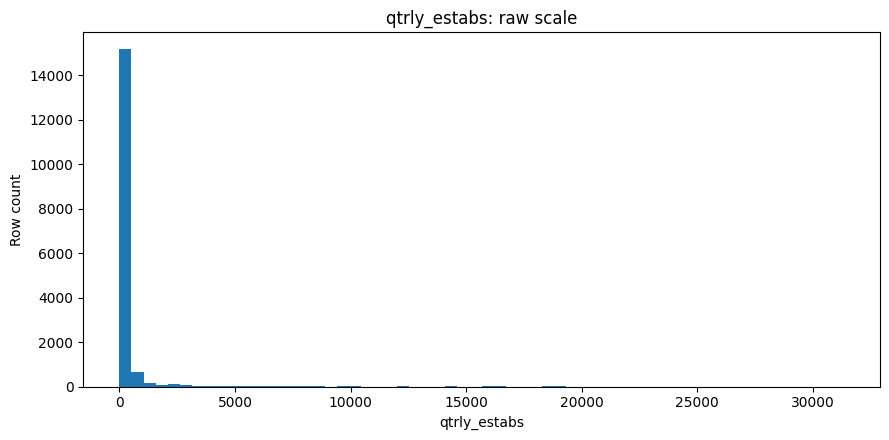

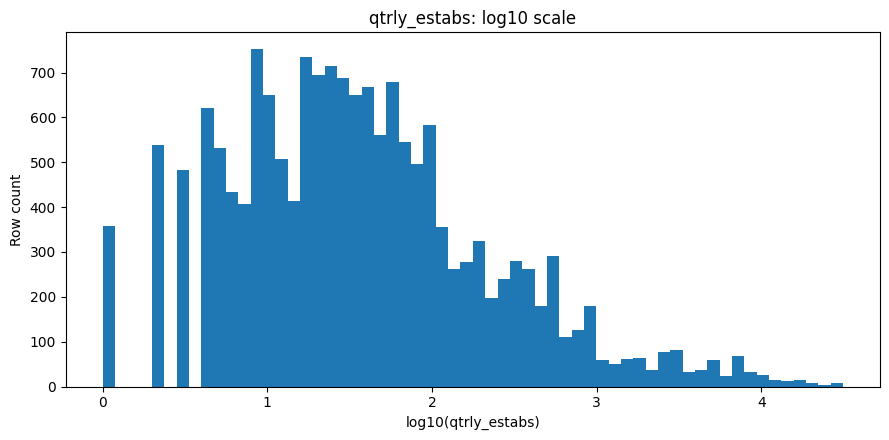

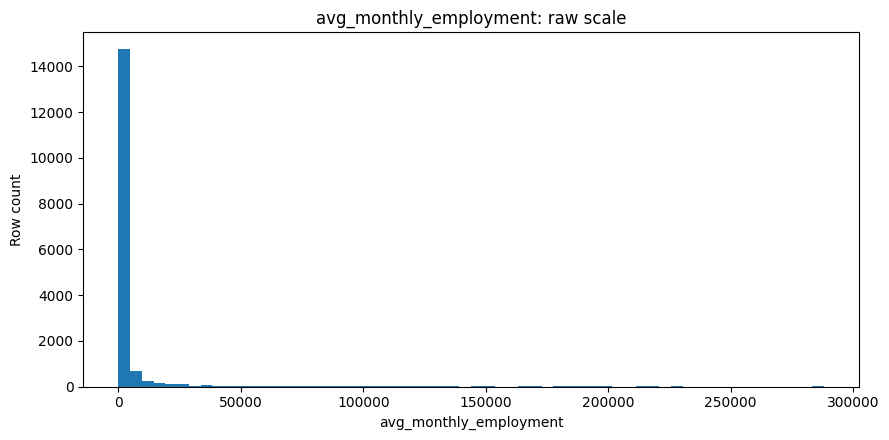

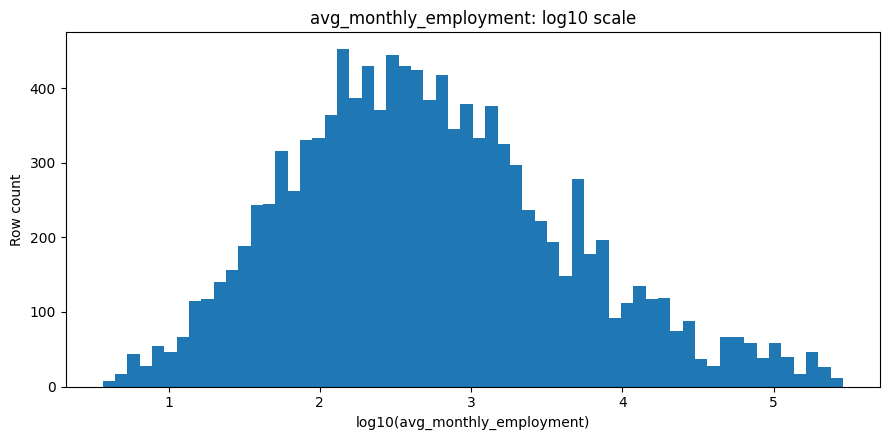

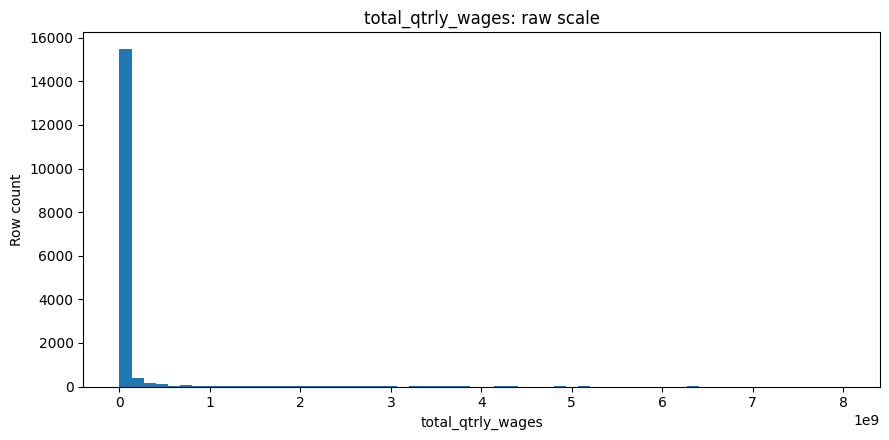

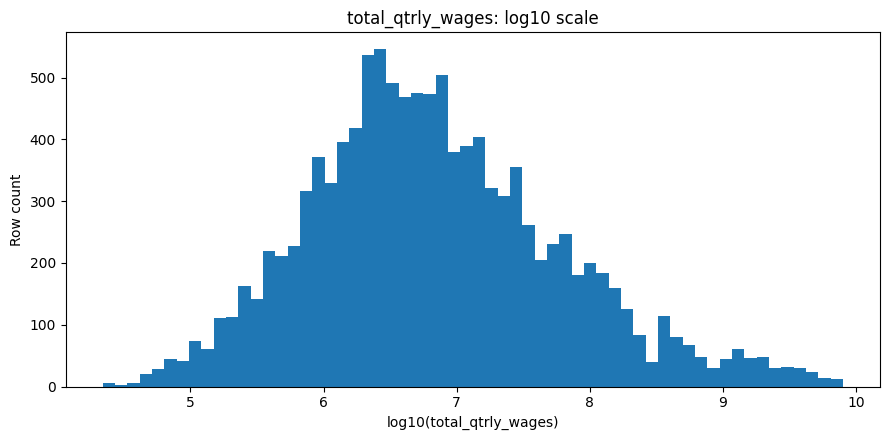

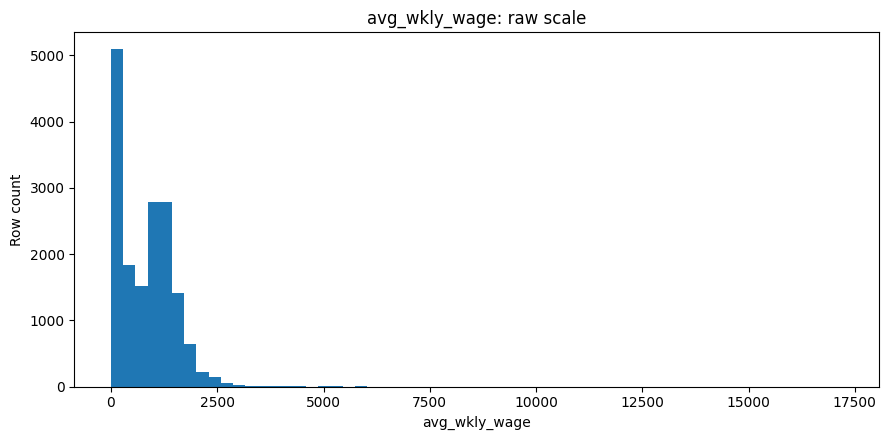

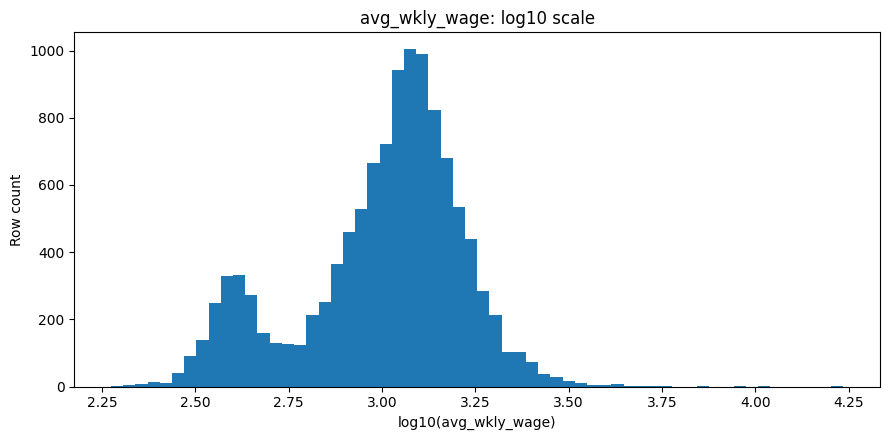

In [18]:
volume_metrics = ["qtrly_estabs", "avg_monthly_employment", "total_qtrly_wages", "avg_wkly_wage"]

for metric in volume_metrics:
    plot_hist(stg_df, metric, bins=60, title=f"{metric}: raw scale")
    plot_hist(stg_df, metric, bins=60, title=f"{metric}: log10 scale", log_x=True)

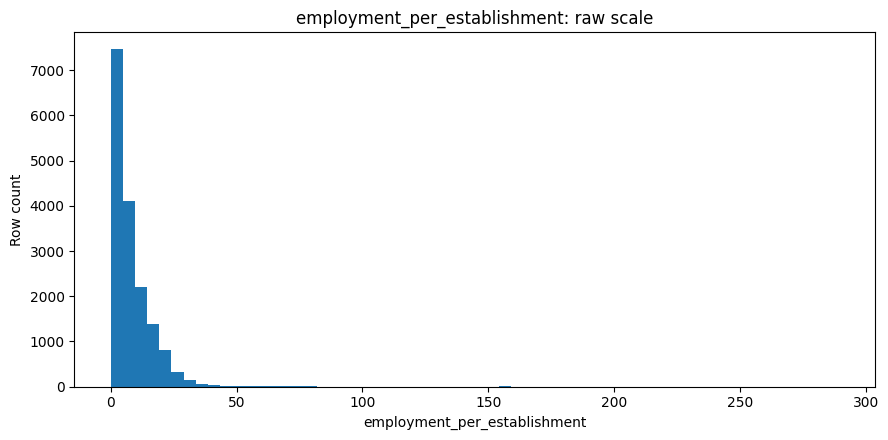

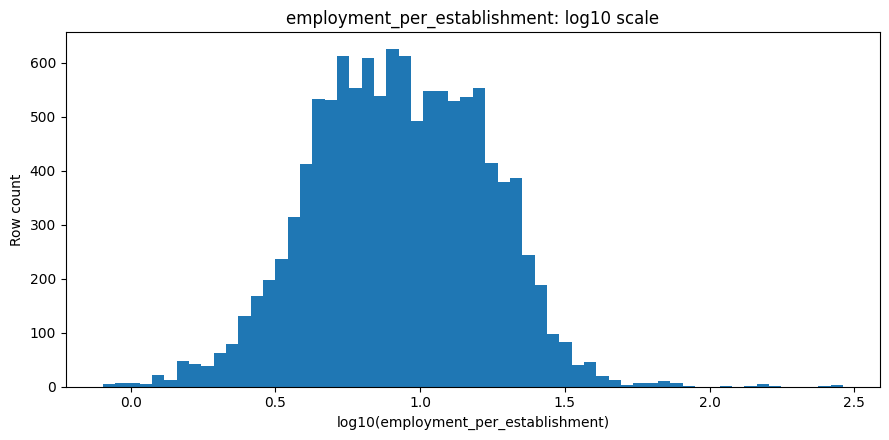

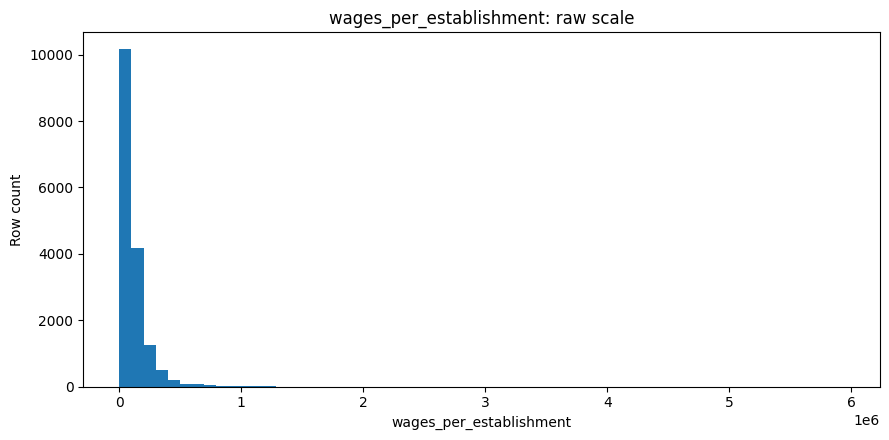

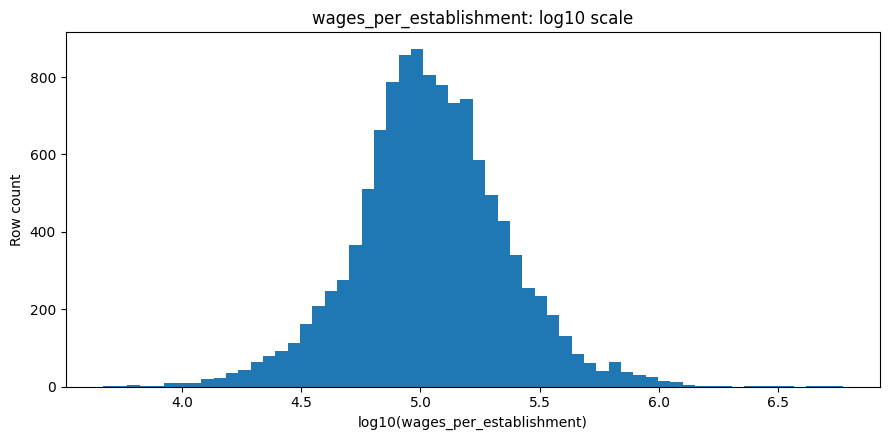

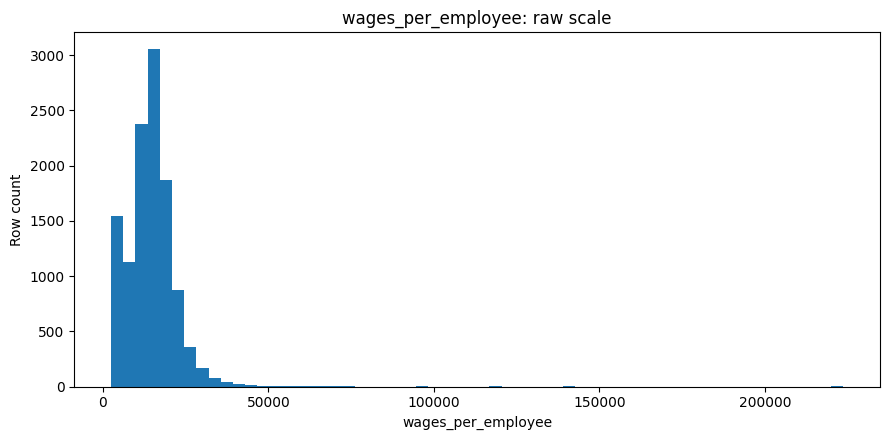

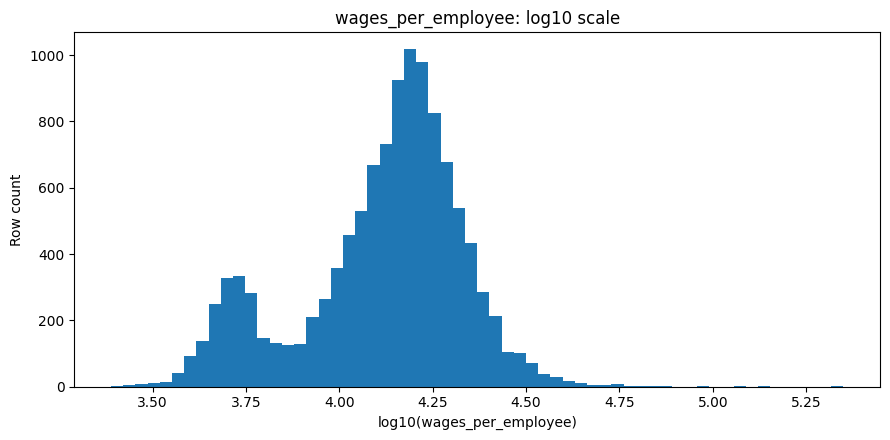

In [19]:
stg_df["employment_per_establishment"] = np.where(
    stg_df["qtrly_estabs"] > 0,
    stg_df["avg_monthly_employment"] / stg_df["qtrly_estabs"],
    np.nan,
)
stg_df["wages_per_establishment"] = np.where(
    stg_df["qtrly_estabs"] > 0,
    stg_df["total_qtrly_wages"] / stg_df["qtrly_estabs"],
    np.nan,
)
stg_df["wages_per_employee"] = np.where(
    stg_df["avg_monthly_employment"] > 0,
    stg_df["total_qtrly_wages"] / stg_df["avg_monthly_employment"],
    np.nan,
)

ratio_metrics = ["employment_per_establishment", "wages_per_establishment", "wages_per_employee"]
for metric in ratio_metrics:
    plot_hist(stg_df, metric, bins=60, title=f"{metric}: raw scale")
    plot_hist(stg_df, metric, bins=60, title=f"{metric}: log10 scale", log_x=True)

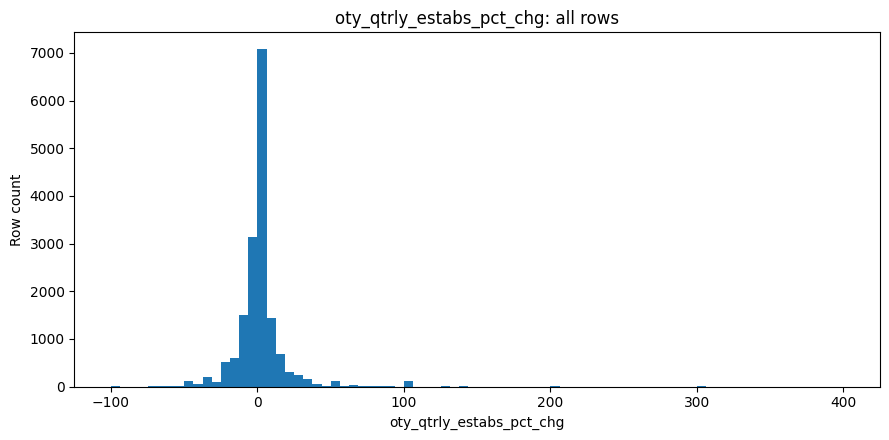

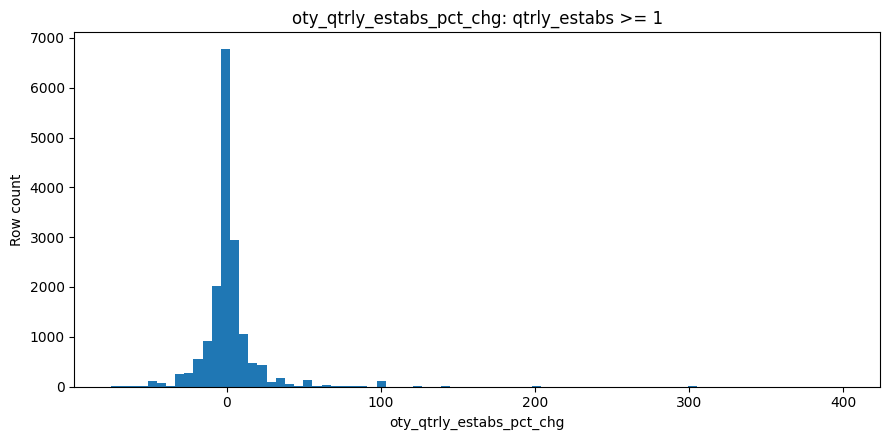

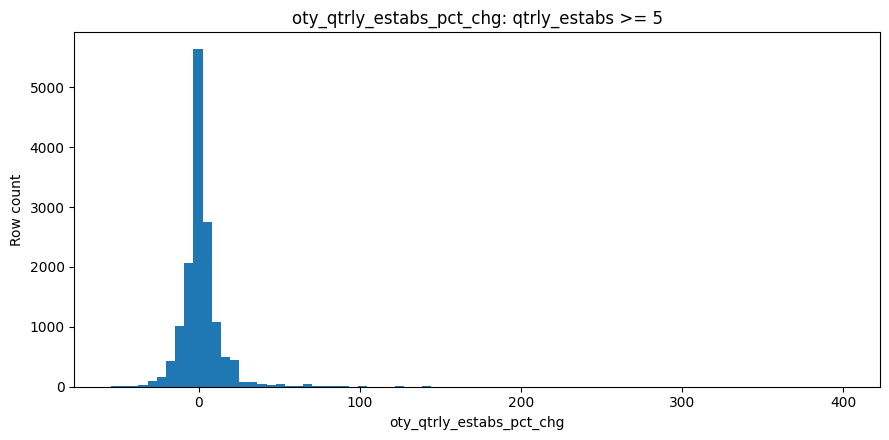

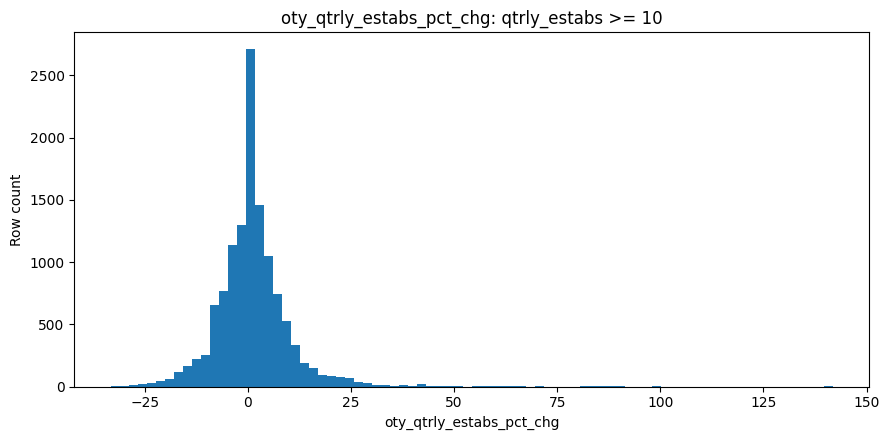

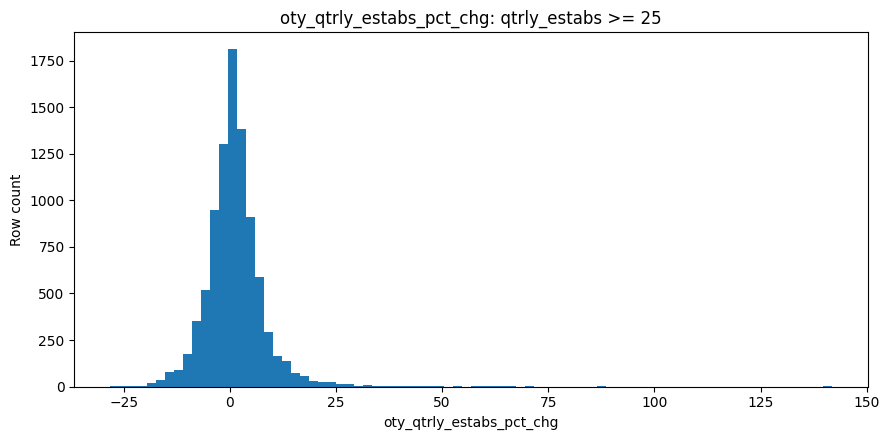

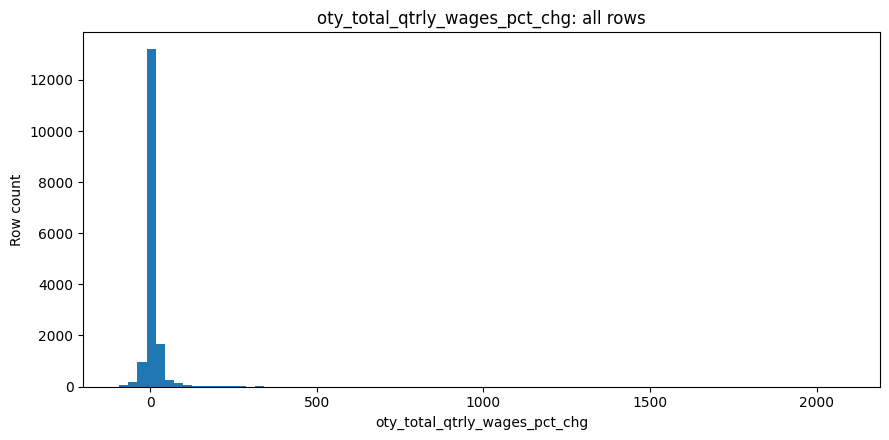

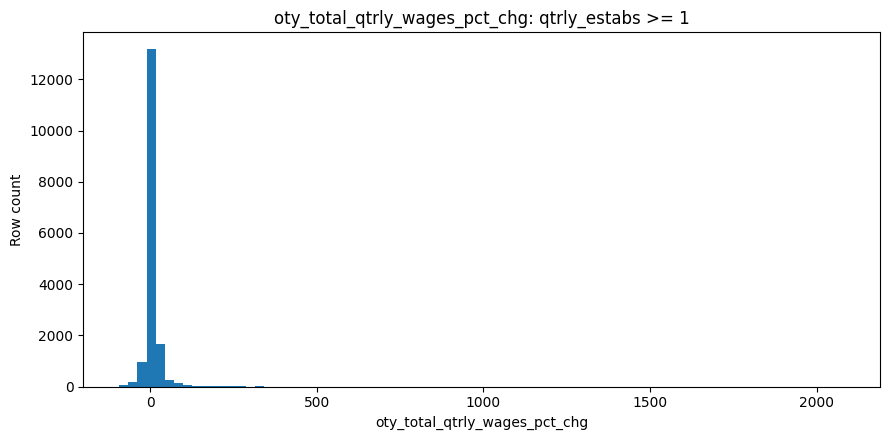

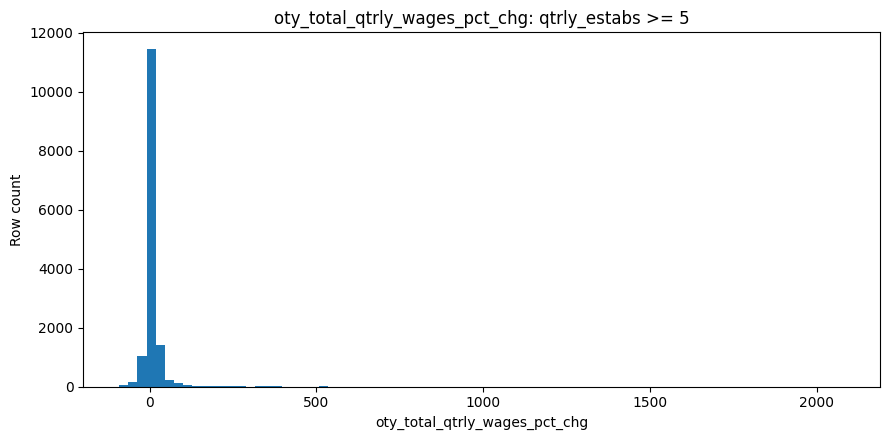

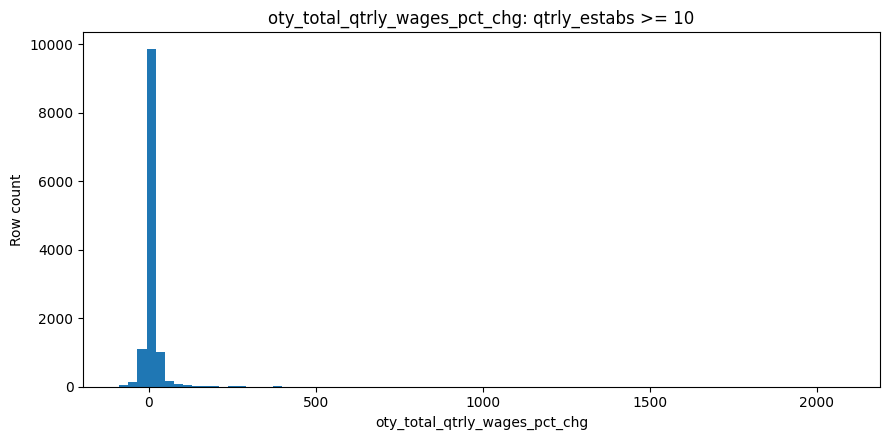

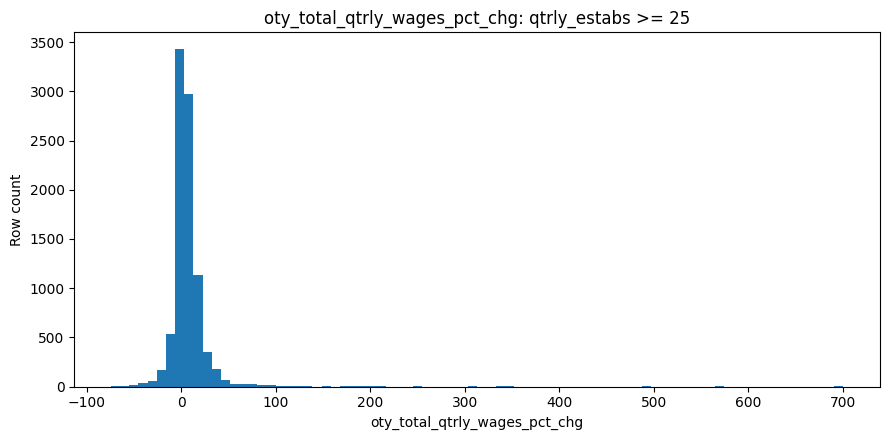

In [20]:
growth_source_metrics = ["oty_qtrly_estabs_pct_chg", "oty_total_qtrly_wages_pct_chg"]

for metric in growth_source_metrics:
    plot_hist(stg_df, metric, bins=80, title=f"{metric}: all rows")
    for threshold in MIN_ESTABS_REVIEW:
        plot_hist(
            stg_df,
            metric,
            bins=80,
            title=f"{metric}: qtrly_estabs >= {threshold}",
            filter_query=f"qtrly_estabs >= {threshold}",
        )

## 7. Percentile tables

Percentiles are more informative than averages for skewed county-industry data. These tables help decide outlier caps, minimum size thresholds, and whether scoring should use percentile ranks.

In [21]:
percentile_metrics = [
    "qtrly_estabs", "avg_monthly_employment", "total_qtrly_wages", "avg_wkly_wage",
    "employment_per_establishment", "wages_per_establishment", "wages_per_employee",
    "oty_qtrly_estabs_pct_chg", "oty_total_qtrly_wages_pct_chg",
]

overall_percentiles = percentile_table(stg_df, percentile_metrics)
display(overall_percentiles)

,metric,p01,p05,p10,p25,p50,p75,p90,p95,p99
0,qtrly_estabs,1.0000,2.0000,4.0000,9.0000,30.0000,97.0000,420.0000,934.7000,"6,726.1200"
1,avg_monthly_employment,0.0000,0.0000,0.0000,0.0000,141.3300,959.5000,"5,363.5320","15,609.0300","102,906.2338"
2,total_qtrly_wages,0.0000,0.0000,0.0000,0.0000,"1,901,563.0000","12,180,772.0000","72,289,990.0000","204,662,079.8000","2,018,515,976.7800"
3,avg_wkly_wage,0.0000,0.0000,0.0000,0.0000,839.0000,"1,255.5000","1,590.0000","1,832.0000","2,492.1400"
4,employment_per_establishment,0.0000,0.0000,0.0000,0.0000,5.5275,11.2894,17.9361,22.0968,33.1598
5,wages_per_establishment,0.0000,0.0000,0.0000,0.0000,"76,082.5263","138,889.6609","227,663.3523","319,400.9000","652,496.9627"
6,wages_per_employee,"3,964.3372","4,855.3909","5,518.1239","10,266.9998","14,451.3922","18,078.9936","22,325.0159","25,490.1812","34,562.4809"
7,oty_qtrly_estabs_pct_chg,-42.9000,-20.0000,-12.5000,-3.9500,0.0000,4.3000,12.9400,23.1000,66.7000
8,oty_total_qtrly_wages_pct_chg,-44.3140,-14.8000,-6.5000,0.0000,0.0000,8.8000,20.2000,32.7700,91.4560


In [22]:
sector_period_percentiles = percentile_table(
    stg_df,
    ["qtrly_estabs", "oty_qtrly_estabs_pct_chg", "oty_total_qtrly_wages_pct_chg"],
    group_cols=["qcew_industry_code", "period_label"],
)

display(sector_period_percentiles.head(50))

,metric,qcew_industry_code,period_label,p01,p05,p10,p25,p50,p75,p90,p95,p99
0,qtrly_estabs,23,2023 Q1,1.5300,4.0000,5.0000,12.0000,37.0000,113.5000,495.0000,844.2000,"4,022.8400"
1,qtrly_estabs,23,2023 Q2,1.5300,4.0000,5.0000,12.0000,37.5000,116.0000,500.3000,849.6000,"4,074.4300"
2,qtrly_estabs,23,2023 Q3,1.0000,4.0000,5.0000,12.0000,37.5000,115.7500,496.7000,843.8000,"4,323.9400"
3,qtrly_estabs,23,2023 Q4,1.0000,3.0000,5.0000,12.0000,38.0000,118.0000,497.1000,838.0000,"4,466.8600"
4,qtrly_estabs,23,2024 Q1,1.0000,4.0000,6.0000,12.0000,37.5000,118.0000,499.2000,833.1000,"4,634.4300"
5,qtrly_estabs,23,2024 Q2,1.0000,4.0000,5.0000,12.0000,37.5000,120.7500,496.4000,835.9000,"4,637.6000"
6,qtrly_estabs,23,2024 Q3,1.0000,4.0000,5.0000,12.0000,38.0000,120.2500,501.4000,845.5500,"4,634.0700"
7,qtrly_estabs,23,2024 Q4,1.0000,4.0000,5.0000,12.0000,38.0000,117.7500,504.2000,838.8000,"4,608.8300"
8,qtrly_estabs,23,2025 Q1,1.5200,4.0000,5.0000,12.0000,38.0000,119.0000,499.6000,836.2000,"4,588.1600"
9,qtrly_estabs,23,2025 Q2,1.5200,4.0000,5.0000,12.0000,38.0000,124.0000,500.2000,851.2000,"4,595.7200"


In [23]:
latest_percentiles = percentile_table(
    latest_df,
    ["qtrly_estabs", "avg_monthly_employment", "total_qtrly_wages", "oty_qtrly_estabs_pct_chg", "oty_total_qtrly_wages_pct_chg"],
    group_cols=["qcew_industry_code"],
)

display(latest_percentiles)

,metric,qcew_industry_code,p01,p05,p10,p25,p50,p75,p90,p95,p99
0,qtrly_estabs,23,2.0000,4.0000,5.0000,11.0000,39.0000,125.0000,497.6000,839.6000,"4,581.5600"
1,qtrly_estabs,52,1.0000,2.0000,4.0000,8.0000,24.0000,66.5000,289.0000,699.0000,"4,161.5000"
2,qtrly_estabs,54,1.0000,2.0000,4.0000,10.0000,30.0000,100.7500,523.6000,"1,087.5000","13,037.6600"
3,qtrly_estabs,56,1.0000,1.0000,2.0000,5.0000,16.0000,57.0000,285.6000,466.2000,"4,117.7600"
4,qtrly_estabs,62,1.0000,3.0000,4.0000,10.0000,29.0000,114.0000,546.0000,"1,450.0000","8,996.5000"
5,qtrly_estabs,72,1.0000,3.0000,5.0000,15.0000,40.0000,103.0000,451.0000,"1,089.8000","4,490.9600"
6,avg_monthly_employment,23,0.0000,0.0000,0.0000,13.0000,326.6700,"1,461.6700","6,210.9360","15,705.0020","58,660.1600"
7,avg_monthly_employment,52,0.0000,0.0000,0.0000,28.5000,137.6700,429.6650,"1,999.6700","5,820.6700","72,922.8350"
8,avg_monthly_employment,54,0.0000,0.0000,0.0000,0.0000,74.0000,459.6675,"3,746.0970","7,549.8200","120,957.6466"
9,avg_monthly_employment,56,0.0000,0.0000,0.0000,0.0000,31.6700,554.3300,"4,225.2700","9,587.0020","71,829.5716"


## 8. Pivot tables and cross-tabs

In [24]:
industry_period_estabs = stg_df.pivot_table(
    index="qcew_industry_code",
    columns="period_label",
    values="qtrly_estabs",
    aggfunc="sum",
    margins=False,
)

display(industry_period_estabs)

period_label,2023 Q1,2023 Q2,2023 Q3,2023 Q4,2024 Q1,2024 Q2,2024 Q3,2024 Q4,2025 Q1,2025 Q2,2025 Q3
qcew_industry_code,,,,,,,,,,,
23,62060,62485,63112,63288,63922,64318,64538,64270,64770,65114,65303
52,47761,47751,48243,48398,48591,48610,48610,48684,48750,48980,49162
54,126529,127488,129592,131056,131767,132334,133300,134006,133959,134225,134732
56,48411,48454,48223,48478,48740,48749,49069,49019,49269,49448,49469
62,97290,97909,99276,100199,100190,100687,101561,102471,102881,103503,104125
72,63219,63675,64207,64617,64907,65212,65625,65598,65905,66276,66429


In [25]:
industry_period_median_yoy = stg_df.pivot_table(
    index="qcew_industry_code",
    columns="period_label",
    values="oty_qtrly_estabs_pct_chg",
    aggfunc="median",
)

display(industry_period_median_yoy)

period_label,2023 Q1,2023 Q2,2023 Q3,2023 Q4,2024 Q1,2024 Q2,2024 Q3,2024 Q4,2025 Q1,2025 Q2,2025 Q3
qcew_industry_code,,,,,,,,,,,
23,0.4500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
52,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
54,0.9000,0.9500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.7000,-0.7000
56,7.3500,4.4000,0.0000,-2.6500,-4.1000,-1.8000,0.0000,0.0000,0.0000,0.0000,0.0000
62,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
72,0.0000,2.6000,1.6000,1.5000,1.2000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [26]:
county_industry_latest_estabs = latest_df.pivot_table(
    index="county_fips",
    columns="qcew_industry_code",
    values="qtrly_estabs",
    aggfunc="sum",
    fill_value=0,
)
county_industry_latest_estabs["total_target_estabs"] = county_industry_latest_estabs.sum(axis=1)
county_industry_latest_estabs = county_industry_latest_estabs.sort_values("total_target_estabs", ascending=False)
display(county_industry_latest_estabs.head(30))

qcew_industry_code,23,52,54,56,62,72,total_target_estabs
county_fips,,,,,,,
48999,7527,6630,31335,8950,13370,2775,70587
48201,8317,6635,18280,6756,15834,10407,66229
48113,5282,5283,14075,5203,9577,6693,46113
48453,3308,2935,12041,3116,5076,3608,30084
48439,3935,3040,6542,2897,6798,4514,27726
48029,3177,2423,6006,2499,8416,4466,26987
48085,1975,2324,7888,2244,5039,2607,22077
48121,1534,1163,3961,1421,2511,1776,12366
48157,1061,1008,3307,894,2838,1471,10579


In [27]:
county_industry_quarter_coverage = stg_df.pivot_table(
    index="county_fips",
    columns="qcew_industry_code",
    values="period_id",
    aggfunc="nunique",
    fill_value=0,
)
county_industry_quarter_coverage["min_observed_quarters"] = county_industry_quarter_coverage.min(axis=1)
county_industry_quarter_coverage = county_industry_quarter_coverage.sort_values("min_observed_quarters")

display(county_industry_quarter_coverage.head(30))

qcew_industry_code,23,52,54,56,62,72,min_observed_quarters
county_fips,,,,,,,
48033,11,11,11,11,11,0,0
48229,11,11,11,11,0,11,0
48247,11,11,0,11,11,11,0
48173,11,11,11,11,0,8,0
48295,11,11,11,11,11,0,0
48269,8,0,11,11,11,0,0
48261,0,11,7,11,11,11,0
48263,11,0,0,11,11,3,0
48393,11,7,11,11,11,0,0


## 9. Prototype growth metrics

This section computes candidate features for the later intermediate model.

In [28]:
metric_df = stg_df.copy()
metric_df = metric_df.sort_values(["county_fips", "qcew_industry_code", "period_id"])
partition_cols = ["county_fips", "qcew_industry_code"]

for current_col, lag_prefix in [
    ("qtrly_estabs", "estabs"),
    ("avg_monthly_employment", "employment"),
    ("total_qtrly_wages", "wages"),
    ("avg_wkly_wage", "avg_wkly_wage"),
]:
    if current_col not in metric_df.columns:
        continue
    metric_df[f"{lag_prefix}_prev_qtr"] = metric_df.groupby(partition_cols)[current_col].shift(1)
    metric_df[f"{lag_prefix}_prev_year"] = metric_df.groupby(partition_cols)[current_col].shift(4)
    metric_df[f"{lag_prefix}_qoq_pct_chg"] = safe_pct_change(metric_df[current_col], metric_df[f"{lag_prefix}_prev_qtr"])
    metric_df[f"{lag_prefix}_yoy_pct_chg"] = safe_pct_change(metric_df[current_col], metric_df[f"{lag_prefix}_prev_year"])
    metric_df[f"{lag_prefix}_4q_avg"] = (
        metric_df.groupby(partition_cols)[current_col]
        .rolling(4, min_periods=2)
        .mean()
        .reset_index(level=partition_cols, drop=True)
    )
    metric_df[f"{lag_prefix}_4q_std"] = (
        metric_df.groupby(partition_cols)[current_col]
        .rolling(4, min_periods=3)
        .std()
        .reset_index(level=partition_cols, drop=True)
    )

metric_df["estabs_growth_acceleration"] = metric_df.groupby(partition_cols)["estabs_qoq_pct_chg"].diff()
metric_df["employment_growth_acceleration"] = metric_df.groupby(partition_cols)["employment_qoq_pct_chg"].diff()
metric_df["wage_growth_acceleration"] = metric_df.groupby(partition_cols)["wages_qoq_pct_chg"].diff()

metric_df["small_market_flag"] = metric_df["qtrly_estabs"] < 10
metric_df["very_small_market_flag"] = metric_df["qtrly_estabs"] < 5
metric_df["zero_estabs_flag"] = metric_df["qtrly_estabs"] == 0
metric_df["missing_source_estabs_yoy_flag"] = metric_df["oty_qtrly_estabs_pct_chg"].isna()
metric_df["extreme_source_estabs_yoy_flag"] = metric_df["oty_qtrly_estabs_pct_chg"].abs() > 100

metric_cols_preview = [
    "county_fips", "qcew_industry_code", "period_label", "qtrly_estabs", "avg_monthly_employment", "total_qtrly_wages",
    "oty_qtrly_estabs_pct_chg", "estabs_qoq_pct_chg", "estabs_yoy_pct_chg", "estabs_4q_avg",
    "employment_qoq_pct_chg", "employment_yoy_pct_chg", "wages_qoq_pct_chg", "wages_yoy_pct_chg",
    "estabs_growth_acceleration", "small_market_flag", "extreme_source_estabs_yoy_flag",
]

display(metric_df[metric_cols_preview].head(30))

,county_fips,qcew_industry_code,period_label,qtrly_estabs,avg_monthly_employment,total_qtrly_wages,oty_qtrly_estabs_pct_chg,estabs_qoq_pct_chg,estabs_yoy_pct_chg,estabs_4q_avg,employment_qoq_pct_chg,employment_yoy_pct_chg,wages_qoq_pct_chg,wages_yoy_pct_chg,estabs_growth_acceleration,small_market_flag,extreme_source_estabs_yoy_flag
0,48001,23,2023 Q1,102,549.3300,"8,353,712.0000",1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
1509,48001,23,2023 Q2,104,568.0000,"8,807,488.0000",1.0000,1.9608,NaN,103.0000,3.3987,NaN,5.4320,NaN,NaN,False,False
3018,48001,23,2023 Q3,103,559.3300,"8,567,601.0000",-1.9000,-0.9615,NaN,103.0000,-1.5264,NaN,-2.7237,NaN,-2.9223,False,False
4527,48001,23,2023 Q4,101,541.0000,"9,013,122.0000",-1.9000,-1.9417,NaN,102.5000,-3.2771,NaN,5.2001,NaN,-0.9802,False,False
6036,48001,23,2024 Q1,103,543.6700,"7,898,332.0000",1.0000,1.9802,0.9804,102.7500,0.4935,-1.0303,-12.3685,-5.4512,3.9219,False,False
7542,48001,23,2024 Q2,104,538.6700,"8,352,205.0000",0.0000,0.9709,0.0000,102.7500,-0.9197,-5.1637,5.7464,-5.1693,-1.0093,False,False
9048,48001,23,2024 Q3,104,537.6700,"8,011,586.0000",1.0000,0.0000,0.9709,103.0000,-0.1856,-3.8725,-4.0782,-6.4897,-0.9709,False,False
10554,48001,23,2024 Q4,103,535.0000,"9,208,209.0000",2.0000,-0.9615,1.9802,103.5000,-0.4966,-1.1091,14.9362,2.1645,-0.9615,False,False
12060,48001,23,2025 Q1,101,556.0000,"8,349,077.0000",-1.9000,-1.9417,-1.9417,103.0000,3.9252,2.2679,-9.3301,5.7068,-0.9802,False,False
13569,48001,23,2025 Q2,103,524.6700,"8,556,911.0000",-1.0000,1.9802,-0.9615,102.7500,-5.6349,-2.5990,2.4893,2.4509,3.9219,False,False


,source_minus_computed_estabs_yoy
count,"10,531.0000"
mean,0.0758
std,2.7554
min,-0.0500
1%,-0.0488
5%,-0.0429
50%,0.0000
95%,0.0429
99%,0.0486
max,100.0000


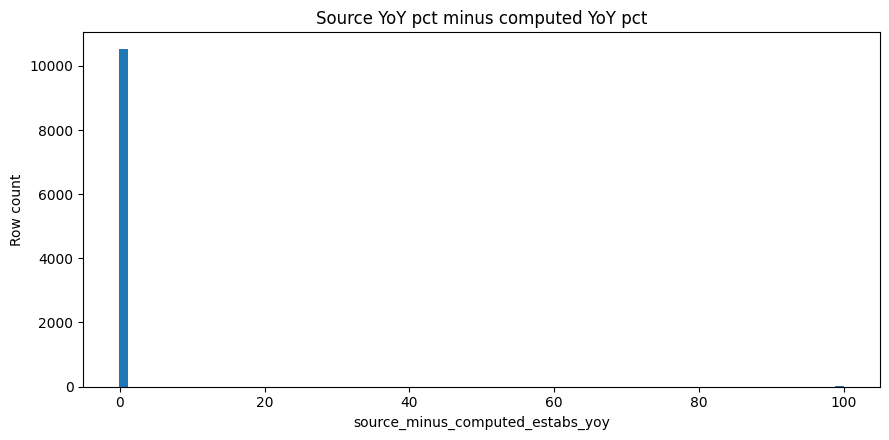

In [ ]:
# Check computed YoY pct change against source YoY pct change
compare_yoy = metric_df.dropna(subset=["oty_qtrly_estabs_pct_chg", "estabs_yoy_pct_chg"]).copy()
compare_yoy["source_minus_computed_estabs_yoy"] = compare_yoy["oty_qtrly_estabs_pct_chg"] - compare_yoy["estabs_yoy_pct_chg"]

yoy_comparison_summary = compare_yoy["source_minus_computed_estabs_yoy"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
display(yoy_comparison_summary.to_frame("source_minus_computed_estabs_yoy"))

plot_hist(compare_yoy, "source_minus_computed_estabs_yoy", bins=80, title="Source YoY pct minus computed YoY pct")

In [30]:
prototype_percentiles = percentile_table(
    metric_df,
    [
        "estabs_qoq_pct_chg", "estabs_yoy_pct_chg", "employment_qoq_pct_chg", "employment_yoy_pct_chg",
        "wages_qoq_pct_chg", "wages_yoy_pct_chg", "estabs_growth_acceleration",
    ],
)

display(prototype_percentiles)

,metric,p01,p05,p10,p25,p50,p75,p90,p95,p99
0,estabs_qoq_pct_chg,-25.0000,-9.0909,-4.9100,-0.9132,0.0000,0.7463,4.2349,8.0000,25.0000
1,estabs_yoy_pct_chg,-45.1515,-20.0000,-13.0435,-4.3478,0.0000,3.4483,11.1111,20.0000,50.0000
2,employment_qoq_pct_chg,-100.0000,-20.1727,-8.8060,-2.5833,0.2490,2.8304,6.9062,12.2820,33.8558
3,employment_yoy_pct_chg,-100.0000,-100.0000,-26.0094,-6.0524,0.8152,5.9857,15.0956,25.9139,76.3365
4,wages_qoq_pct_chg,-100.0000,-37.3375,-17.9584,-6.1521,0.9754,7.9578,17.4799,28.0041,67.4067
5,wages_yoy_pct_chg,-100.0000,-100.0000,-30.5192,-3.8696,4.4289,11.7226,23.4364,38.1451,118.8938
6,estabs_growth_acceleration,-33.3333,-14.2857,-8.2078,-2.1391,0.0000,2.0833,7.6923,14.2857,33.3333


The query and graph shows that differences between QCEW's calculated percent changes and ours are centered around 0. This is in favor of the accuracy of our computation.

## 10. Small-denominator and outlier checks

Extreme growth rates are often caused by small denominators. This section identifies whether the score needs a minimum-size threshold or a confidence flag.

In [31]:
outlier_summary = []
for threshold in MIN_ESTABS_REVIEW:
    subset = metric_df[metric_df["qtrly_estabs"] >= threshold]
    outlier_summary.append({
        "min_estabs_threshold": threshold,
        "rows": len(subset),
        "row_share": len(subset) / len(metric_df) if len(metric_df) else np.nan,
        "median_estabs_yoy_pct_chg": subset["estabs_yoy_pct_chg"].median(),
        "p95_abs_estabs_yoy_pct_chg": subset["estabs_yoy_pct_chg"].abs().quantile(0.95),
        "extreme_source_yoy_share_abs_gt_100": (subset["oty_qtrly_estabs_pct_chg"].abs() > 100).mean(),
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df)

,min_estabs_threshold,rows,row_share,median_estabs_yoy_pct_chg,p95_abs_estabs_yoy_pct_chg,extreme_source_yoy_share_abs_gt_100
0,1,16561,0.9984,0.0000,33.3333,0.0010
1,5,14564,0.8780,0.0000,22.2222,0.0008
2,10,12439,0.7499,0.0000,16.6667,0.0002
3,25,9094,0.5483,0.0000,13.0435,0.0001


In [32]:
top_growth = metric_df.sort_values("estabs_yoy_pct_chg", ascending=False).head(50)
bottom_growth = metric_df.sort_values("estabs_yoy_pct_chg", ascending=True).head(50)

cols = [
    "county_fips", "qcew_industry_code", "period_label", "qtrly_estabs", "estabs_prev_year",
    "estabs_yoy_pct_chg", "avg_monthly_employment", "employment_yoy_pct_chg", "total_qtrly_wages", "wages_yoy_pct_chg",
    "small_market_flag",
]

print("Top 50 computed YoY establishment growth rows")
display(top_growth[cols])
print("Bottom 50 computed YoY establishment growth rows")
display(bottom_growth[cols])

Top 50 computed YoY establishment growth rows


,county_fips,qcew_industry_code,period_label,qtrly_estabs,estabs_prev_year,estabs_yoy_pct_chg,avg_monthly_employment,employment_yoy_pct_chg,total_qtrly_wages,wages_yoy_pct_chg,small_market_flag
14041,48447,52,2025 Q2,4,1.0000,300.0000,0.0000,NaN,0.0000,NaN,True
12532,48447,52,2025 Q1,4,1.0000,300.0000,0.0000,NaN,0.0000,NaN,True
15550,48447,52,2025 Q3,4,1.0000,300.0000,0.0000,NaN,0.0000,NaN,True
14459,48271,56,2025 Q2,3,1.0000,200.0000,0.0000,NaN,0.0000,NaN,True
9757,48417,54,2024 Q3,7,3.0000,133.3333,0.0000,NaN,0.0000,NaN,True
11479,48343,56,2024 Q4,9,4.0000,125.0000,0.0000,NaN,0.0000,NaN,True
9973,48343,56,2024 Q3,9,4.0000,125.0000,0.0000,NaN,0.0000,NaN,True
13775,48417,23,2025 Q2,9,4.0000,125.0000,40.6700,NaN,"726,699.0000",NaN,True
14850,48045,72,2025 Q2,4,2.0000,100.0000,0.0000,NaN,0.0000,NaN,True
14532,48417,56,2025 Q2,4,2.0000,100.0000,29.3300,NaN,"992,995.0000",NaN,True


Bottom 50 computed YoY establishment growth rows


,county_fips,qcew_industry_code,period_label,qtrly_estabs,estabs_prev_year,estabs_yoy_pct_chg,avg_monthly_employment,employment_yoy_pct_chg,total_qtrly_wages,wages_yoy_pct_chg,small_market_flag
11271,48433,54,2024 Q4,0,1.0000,-100.0000,0.0000,NaN,0.0000,NaN,True
12777,48433,54,2025 Q1,0,1.0000,-100.0000,0.0000,NaN,0.0000,NaN,True
14487,48327,56,2025 Q2,0,1.0000,-100.0000,0.0000,NaN,0.0000,NaN,True
15996,48327,56,2025 Q3,0,1.0000,-100.0000,0.0000,NaN,0.0000,NaN,True
8415,48235,56,2024 Q2,0,2.0000,-100.0000,0.0000,NaN,0.0000,NaN,True
9921,48235,56,2024 Q3,0,2.0000,-100.0000,0.0000,NaN,0.0000,NaN,True
16215,48261,62,2025 Q3,0,1.0000,-100.0000,0.0000,NaN,0.0000,NaN,True
11427,48235,56,2024 Q4,0,2.0000,-100.0000,0.0000,NaN,0.0000,NaN,True
9939,48271,56,2024 Q3,0,1.0000,-100.0000,0.0000,NaN,0.0000,NaN,True
12974,48319,56,2025 Q1,0,1.0000,-100.0000,0.0000,NaN,0.0000,NaN,True


The query above confirms that extreme growth rates are due to small denominators from the previous period.

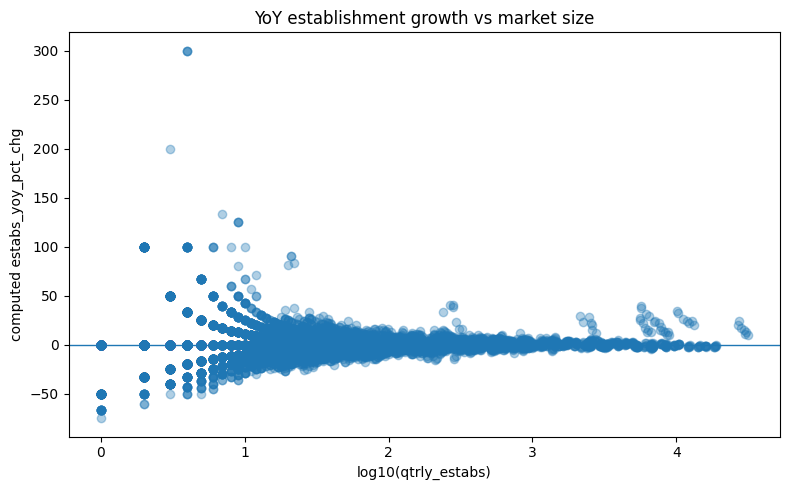

In [33]:
scatter_df = metric_df.dropna(subset=["qtrly_estabs", "estabs_yoy_pct_chg"]).copy()
scatter_df = scatter_df[scatter_df["qtrly_estabs"] > 0]

plt.figure(figsize=(8, 5))
plt.scatter(np.log10(scatter_df["qtrly_estabs"]), scatter_df["estabs_yoy_pct_chg"], alpha=0.35)
plt.axhline(0, linewidth=1)
plt.title("YoY establishment growth vs market size")
plt.xlabel("log10(qtrly_estabs)")
plt.ylabel("computed estabs_yoy_pct_chg")
plt.tight_layout()
plt.show()

## 11. Prototype ongoing growth scores

These are candidate descriptive scores. They are useful for comparing scoring approaches before writing production SQL.

Scoring principle:

- Rank county-industries within the same `period × industry`.
- Use percentiles instead of raw growth values to reduce scale and outlier problems.
- Compare multiple candidate formulas before deciding.

In [ ]:
score_df = metric_df.copy()
score_group_cols = ["period_id", "qcew_industry_code"]

rank_inputs = {
    "estabs_yoy_rank": "estabs_yoy_pct_chg",
    "employment_yoy_rank": "employment_yoy_pct_chg",
    "wages_yoy_rank": "wages_yoy_pct_chg",
    "estabs_qoq_rank": "estabs_qoq_pct_chg",
    "employment_qoq_rank": "employment_qoq_pct_chg",
    "wages_qoq_rank": "wages_qoq_pct_chg",
    "estabs_acceleration_rank": "estabs_growth_acceleration",
}

for rank_col, source_col in rank_inputs.items():
    if source_col in score_df.columns:
        score_df[f"{source_col}_winsor"] = score_df.groupby(score_group_cols)[source_col].transform(winsorize_series)
        score_df[rank_col] = score_df.groupby(score_group_cols)[f"{source_col}_winsor"].transform(pct_rank_0_100)

score_df["ongoing_growth_score_yoy_v0"] = (
    0.50 * score_df["estabs_yoy_rank"]
    + 0.25 * score_df["employment_yoy_rank"]
    + 0.25 * score_df["wages_yoy_rank"]
)

score_df["ongoing_growth_score_qoq_yoy_v0"] = (
    0.35 * score_df["estabs_yoy_rank"]
    + 0.20 * score_df["employment_yoy_rank"]
    + 0.20 * score_df["wages_yoy_rank"]
    + 0.15 * score_df["estabs_qoq_rank"]
    + 0.10 * score_df["employment_qoq_rank"]
)

# Heuristic: accleration -> future growth trend; but not tested, predictive power unknown
score_df["expected_growth_score_proxy_v0"] = (
    0.40 * score_df["estabs_yoy_rank"]
    + 0.25 * score_df["estabs_acceleration_rank"]
    + 0.20 * score_df["employment_yoy_rank"]
    + 0.15 * score_df["wages_yoy_rank"]
)

# Heuristic: small establishments produce unstable changes -> lower confidence; larger produce more stable changes -> higher confidence
# However, this introduces bias against small markets, might need improvement
score_df["score_confidence"] = np.select(
    [
        score_df["qtrly_estabs"] >= 25,
        score_df["qtrly_estabs"] >= 10,
        score_df["qtrly_estabs"] >= 5,
    ],
    ["high", "medium", "low"],
    default="very_low",
)

score_cols = [
    "county_fips", "qcew_industry_code", "period_label", "qtrly_estabs",
    "estabs_yoy_pct_chg", "employment_yoy_pct_chg", "wages_yoy_pct_chg",
    "ongoing_growth_score_yoy_v0", "ongoing_growth_score_qoq_yoy_v0", "expected_growth_score_proxy_v0",
    "score_confidence",
]

latest_score_df = score_df[score_df["period_id"] == latest_period_id].copy()
latest_score_df = latest_score_df.sort_values("ongoing_growth_score_yoy_v0", ascending=False)

display(latest_score_df[score_cols].head(50))

,county_fips,qcew_industry_code,period_label,qtrly_estabs,estabs_yoy_pct_chg,employment_yoy_pct_chg,wages_yoy_pct_chg,ongoing_growth_score_yoy_v0,ongoing_growth_score_qoq_yoy_v0,expected_growth_score_proxy_v0,score_confidence
16250,48333,62,2025 Q3,13,30.0000,53.3598,74.6555,99.6377,83.3553,87.3264,medium
15587,48011,54,2025 Q3,9,50.0000,72.5021,123.1116,99.4571,92.8834,74.9785,low
15448,48237,52,2025 Q3,5,25.0000,25.9444,29.0858,97.9511,90.7172,87.7005,low
16276,48385,62,2025 Q3,8,33.3333,12.6371,20.9165,97.6896,88.9781,97.0640,low
15451,48243,52,2025 Q3,5,66.6667,11.1111,35.7399,97.6057,92.2849,98.1069,low
15809,48461,54,2025 Q3,6,20.0000,64.3087,118.1174,97.5471,85.1454,86.7907,low
16291,48415,62,2025 Q3,23,21.0526,41.5690,17.6867,97.2201,81.9440,75.9858,medium
16337,48999,62,2025 Q3,13370,19.8029,19.4926,26.7007,96.8260,96.7066,90.4257,high
16488,48311,72,2025 Q3,5,25.0000,11.2724,17.5217,96.6913,81.0075,86.4791,low
16459,48247,72,2025 Q3,10,11.1111,50.2698,73.1078,96.0160,81.5233,95.0136,medium


In [35]:
score_comparison = score_df[[
    "ongoing_growth_score_yoy_v0",
    "ongoing_growth_score_qoq_yoy_v0",
    "expected_growth_score_proxy_v0",
]].corr(method="spearman")

display(score_comparison)

,ongoing_growth_score_yoy_v0,ongoing_growth_score_qoq_yoy_v0,expected_growth_score_proxy_v0
ongoing_growth_score_yoy_v0,1.0000,0.9669,0.9234
ongoing_growth_score_qoq_yoy_v0,0.9669,1.0000,0.9502
expected_growth_score_proxy_v0,0.9234,0.9502,1.0000


The metrics are highly correlated. That is reasonable between YoY and QoQ scores. Expected growth score is also highly redundant with the other two, which implies it likely doesn't say much about expected growth.

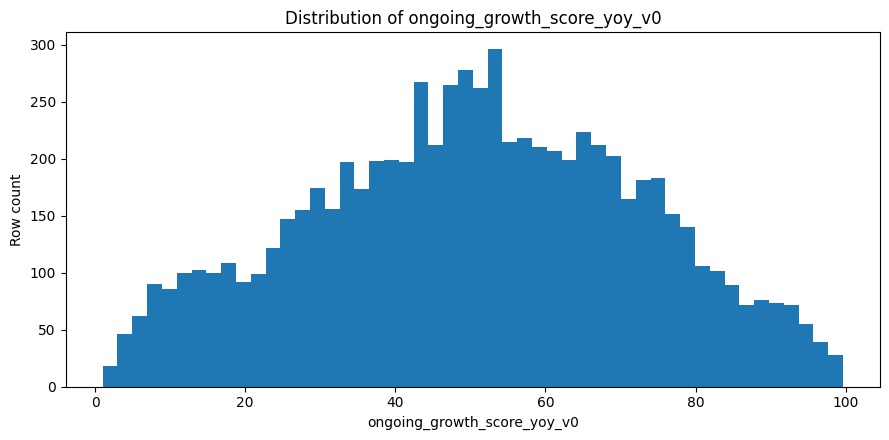

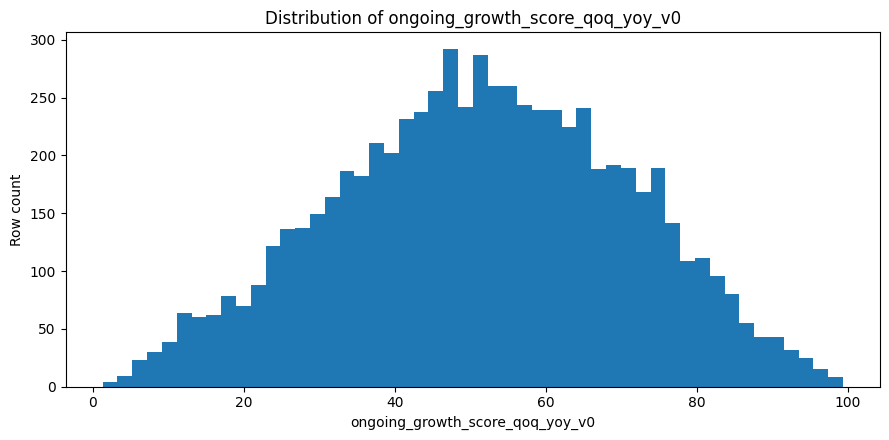

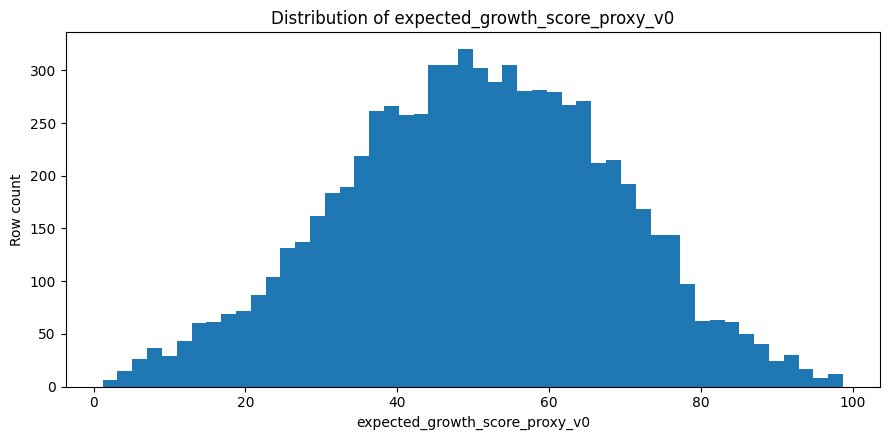

In [36]:
for score_col in ["ongoing_growth_score_yoy_v0", "ongoing_growth_score_qoq_yoy_v0", "expected_growth_score_proxy_v0"]:
    plot_hist(score_df, score_col, bins=50, title=f"Distribution of {score_col}")

## 12. Seasonality checks

This helps distinguish true market momentum from quarter-specific patterns.

In [37]:
seasonality_summary = (
    metric_df.groupby(["quarter", "qcew_industry_code"])
    .agg(
        rows=("county_fips", "size"),
        median_estabs_qoq_pct_chg=("estabs_qoq_pct_chg", "median"),
        median_employment_qoq_pct_chg=("employment_qoq_pct_chg", "median"),
        median_wages_qoq_pct_chg=("wages_qoq_pct_chg", "median"),
        p75_estabs_qoq_pct_chg=("estabs_qoq_pct_chg", lambda s: s.quantile(0.75)),
        p25_estabs_qoq_pct_chg=("estabs_qoq_pct_chg", lambda s: s.quantile(0.25)),
    )
    .reset_index()
    .sort_values(["qcew_industry_code", "quarter"])
)

display(seasonality_summary)

,quarter,qcew_industry_code,rows,median_estabs_qoq_pct_chg,median_employment_qoq_pct_chg,median_wages_qoq_pct_chg,p75_estabs_qoq_pct_chg,p25_estabs_qoq_pct_chg
0,1,23,761,0.0000,-1.0418,-11.5884,2.2018,-1.2669
6,2,23,761,0.0000,2.2151,5.2990,1.6405,-0.0757
12,3,23,761,0.0000,0.4344,2.6429,0.5435,-0.8362
18,4,23,508,0.0000,0.2820,11.4796,0.0000,-1.7857
1,1,52,754,0.0000,-0.6387,-2.0606,0.0000,-1.1398
7,2,52,754,0.0000,0.5741,-8.4633,0.0000,0.0000
13,3,52,754,0.0000,0.4255,-1.2613,0.0000,0.0000
19,4,52,503,0.0000,0.0000,18.2716,0.0000,-0.4943
2,1,54,755,0.0000,0.0000,-10.8098,1.5923,-2.7482
8,2,54,755,0.0000,0.1004,1.7566,1.0638,-0.5988


In [38]:
seasonality_pivot = seasonality_summary.pivot_table(
    index="qcew_industry_code",
    columns="quarter",
    values="median_estabs_qoq_pct_chg",
)

display(seasonality_pivot)

quarter,1,2,3,4
qcew_industry_code,,,,
23,0.0000,0.0000,0.0000,0.0000
52,0.0000,0.0000,0.0000,0.0000
54,0.0000,0.0000,0.0000,0.0000
56,0.0000,0.0000,0.0000,0.0000
62,0.0000,0.0000,0.0000,0.0000
72,0.0000,0.0000,0.0000,0.0000


In [49]:
# Check whether the all-zero median is hiding variation.
seasonality_diagnostics = (
    metric_df
    .groupby(["qcew_industry_code", "quarter"])
    .agg(
        rows=("county_fips", "size"),
        mean_estabs_qoq=("estabs_qoq_pct_chg", "mean"),
        median_estabs_qoq=("estabs_qoq_pct_chg", "median"),
        std_estabs_qoq=("estabs_qoq_pct_chg", "std"),
        p25_estabs_qoq=("estabs_qoq_pct_chg", lambda s: s.quantile(0.25)),
        p75_estabs_qoq=("estabs_qoq_pct_chg", lambda s: s.quantile(0.75)),
        p90_estabs_qoq=("estabs_qoq_pct_chg", lambda s: s.quantile(0.90)),
        pct_nonzero_estabs_qoq=(
            "estabs_qoq_pct_chg",
            lambda s: s.fillna(0).ne(0).mean() * 100,
        ),
    )
    .reset_index()
)

display(seasonality_diagnostics.round(4))

,qcew_industry_code,quarter,rows,mean_estabs_qoq,median_estabs_qoq,std_estabs_qoq,p25_estabs_qoq,p75_estabs_qoq,p90_estabs_qoq,pct_nonzero_estabs_qoq
0,23,1,761,0.9789,0.0000,8.3666,-1.2669,2.2018,7.6923,46.6491
1,23,2,761,0.3197,0.0000,7.0595,-0.0757,1.6405,4.7619,64.3890
2,23,3,761,0.1163,0.0000,7.4977,-0.8362,0.5435,3.2258,60.0526
3,23,4,508,-0.5766,0.0000,5.8089,-1.7857,0.0000,2.8696,60.8268
4,52,1,754,0.3431,0.0000,15.0152,-1.1398,0.0000,4.9283,37.1353
5,52,2,754,0.1048,0.0000,4.6213,0.0000,0.0000,3.0303,45.6233
6,52,3,754,0.2179,0.0000,4.9730,0.0000,0.0000,3.1250,45.6233
7,52,4,503,-0.3648,0.0000,4.7695,-0.4943,0.0000,2.1739,46.3221
8,54,1,755,-0.6815,0.0000,7.7971,-2.7482,1.5923,6.7792,47.4172
9,54,2,755,0.1720,0.0000,7.9786,-0.5988,1.0638,4.8387,61.9868


Not much seasonality effect observed.

## 13. County concentration checks

If a few large counties dominate the target sectors, the dashboard should separate large-market views from emerging-market views.

In [39]:
county_latest = (
    latest_df.groupby("county_fips")
    .agg(
        establishments=("qtrly_estabs", "sum"),
        avg_monthly_employment=("avg_monthly_employment", "sum"),
        total_qtrly_wages=("total_qtrly_wages", "sum"),
        industries=("qcew_industry_code", "nunique"),
    )
    .reset_index()
    .sort_values("establishments", ascending=False)
)
county_latest["establishment_share"] = county_latest["establishments"] / county_latest["establishments"].sum()
county_latest["cumulative_establishment_share"] = county_latest["establishment_share"].cumsum()

display(county_latest.head(30))

,county_fips,establishments,avg_monthly_employment,total_qtrly_wages,industries,establishment_share,cumulative_establishment_share
254,48999,70587,"368,621.6700","8,765,140,151.0000",6,0.1504,0.1504
100,48201,66229,"1,174,675.6600","23,371,250,562.0000",6,0.1411,0.2916
56,48113,46113,"912,087.3200","19,871,559,923.0000",6,0.0983,0.3899
226,48453,30084,"472,027.0000","11,815,384,373.0000",6,0.0641,0.4540
219,48439,27726,"460,608.0100","8,005,923,528.0000",6,0.0591,0.5131
14,48029,26987,"466,595.3300","7,481,358,729.0000",6,0.0575,0.5706
42,48085,22077,"306,187.3400","6,914,501,873.0000",6,0.0471,0.6176
60,48121,12366,"146,155.6700","2,429,189,743.0000",6,0.0264,0.6440
78,48157,10579,"112,343.3400","1,748,905,576.0000",6,0.0225,0.6665
245,48491,9552,"123,209.3300","2,481,050,595.0000",6,0.0204,0.6869


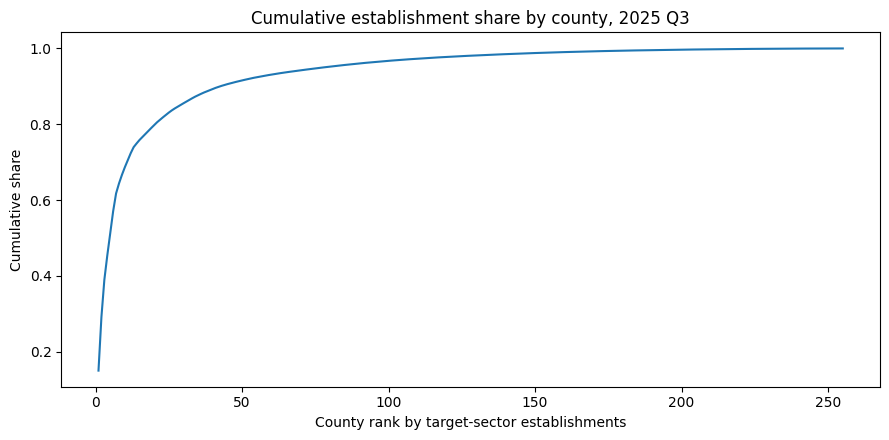

In [40]:
plt.figure(figsize=(9, 4.5))
plt.plot(np.arange(1, len(county_latest) + 1), county_latest["cumulative_establishment_share"])
plt.title(f"Cumulative establishment share by county, {latest_period_label}")
plt.xlabel("County rank by target-sector establishments")
plt.ylabel("Cumulative share")
plt.tight_layout()
plt.show()

Less than 50 counties account for over 80% of target-sector establishments. This suggests SMB activity is highly concentrated in a small number of large counties.
Dashboard may need option to filter by county size tiers, otherwise big counties would likely dominate every view.

## 14. Predictive signal checks

This section tests whether current growth metrics contain any signal for future establishment growth.

Lightweight predictive sanity check, **not causal explanatory power**.

Targets:

- `next_qtr_estabs_pct_chg`: next-quarter establishment growth
- `positive_next_qtr_estabs_growth`: whether next-quarter establishment growth is positive
- `next_4q_estabs_pct_chg`: four-quarter-ahead establishment growth, when enough future data exists

In [41]:
signal_df = score_df.copy().sort_values(partition_cols + ["period_id"])

signal_df["next_qtr_estabs"] = signal_df.groupby(partition_cols)["qtrly_estabs"].shift(-1)
signal_df["next_4q_estabs"] = signal_df.groupby(partition_cols)["qtrly_estabs"].shift(-4)
signal_df["next_qtr_estabs_pct_chg"] = safe_pct_change(signal_df["next_qtr_estabs"], signal_df["qtrly_estabs"])
signal_df["next_4q_estabs_pct_chg"] = safe_pct_change(signal_df["next_4q_estabs"], signal_df["qtrly_estabs"])
signal_df["positive_next_qtr_estabs_growth"] = (signal_df["next_qtr_estabs_pct_chg"] > 0).astype(float)

feature_cols = [
    "qtrly_estabs", "avg_monthly_employment", "total_qtrly_wages", "avg_wkly_wage",
    "estabs_qoq_pct_chg", "employment_qoq_pct_chg", "wages_qoq_pct_chg",
    "estabs_yoy_pct_chg", "employment_yoy_pct_chg", "wages_yoy_pct_chg",
    "estabs_growth_acceleration", "employment_growth_acceleration", "wage_growth_acceleration",
    "ongoing_growth_score_yoy_v0", "ongoing_growth_score_qoq_yoy_v0", "expected_growth_score_proxy_v0",
]
feature_cols = [c for c in feature_cols if c in signal_df.columns]

modeling_df = signal_df.dropna(subset=["next_qtr_estabs_pct_chg"]).copy()
print(f"Rows with next-quarter target: {len(modeling_df):,}")
print(f"Available periods with next-quarter target: {modeling_df['period_label'].nunique():,}")

Rows with next-quarter target: 15,053
Available periods with next-quarter target: 10


In [42]:
corr_cols = feature_cols + ["next_qtr_estabs_pct_chg", "next_4q_estabs_pct_chg"]
spearman_corr = modeling_df[corr_cols].corr(method="spearman")[["next_qtr_estabs_pct_chg", "next_4q_estabs_pct_chg"]].sort_values(
    "next_qtr_estabs_pct_chg", ascending=False
)

display(spearman_corr)

,next_qtr_estabs_pct_chg,next_4q_estabs_pct_chg
next_qtr_estabs_pct_chg,1.0000,0.4313
next_4q_estabs_pct_chg,0.4313,1.0000
employment_yoy_pct_chg,0.0478,0.0297
avg_monthly_employment,0.0443,0.0722
total_qtrly_wages,0.0416,0.0679
wages_yoy_pct_chg,0.0415,0.0394
ongoing_growth_score_qoq_yoy_v0,0.0307,0.0471
employment_qoq_pct_chg,0.0306,0.0640
qtrly_estabs,0.0306,0.0483
ongoing_growth_score_yoy_v0,0.0281,0.0305


,score_decile,rows,avg_score,median_next_qtr_growth,mean_next_qtr_growth,positive_growth_rate
0,1,636,11.9164,0.0000,0.0041,0.2406
1,2,635,25.5554,0.0000,-0.3347,0.2756
2,3,635,34.5154,0.0000,0.0566,0.3134
3,4,636,42.0241,0.0000,-0.1521,0.3066
4,5,635,48.1696,0.0000,0.0775,0.3386
5,6,635,53.5560,0.0000,-0.0116,0.3654
6,7,637,60.0288,0.0000,-0.1490,0.3454
7,8,634,66.8700,0.0000,0.0849,0.3675
8,9,635,74.6404,0.0000,-0.0861,0.3669
9,10,636,87.4274,0.0000,0.2028,0.3160


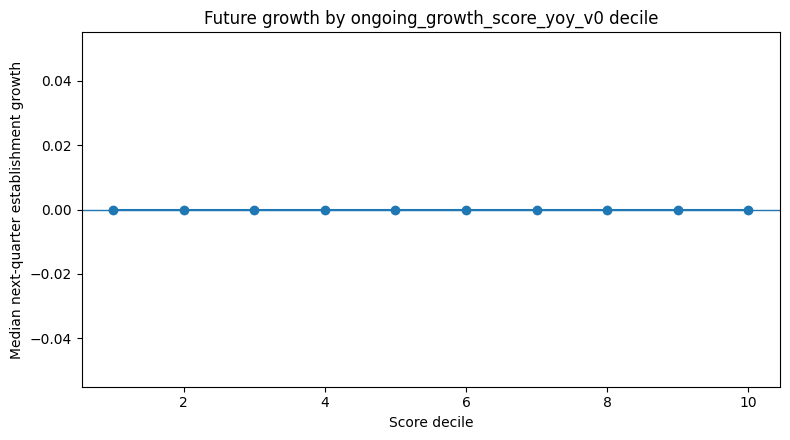

In [43]:
score_to_test = "ongoing_growth_score_yoy_v0"
score_signal_df = modeling_df.dropna(subset=[score_to_test, "next_qtr_estabs_pct_chg"]).copy()
score_signal_df["score_decile"] = pd.qcut(score_signal_df[score_to_test], q=10, labels=False, duplicates="drop") + 1

score_decile_summary = (
    score_signal_df.groupby("score_decile")
    .agg(
        rows=("county_fips", "size"),
        avg_score=(score_to_test, "mean"),
        median_next_qtr_growth=("next_qtr_estabs_pct_chg", "median"),
        mean_next_qtr_growth=("next_qtr_estabs_pct_chg", "mean"),
        positive_growth_rate=("positive_next_qtr_estabs_growth", "mean"),
    )
    .reset_index()
)

display(score_decile_summary)

plt.figure(figsize=(8, 4.5))
plt.plot(score_decile_summary["score_decile"], score_decile_summary["median_next_qtr_growth"], marker="o")
plt.axhline(0, linewidth=1)
plt.title(f"Future growth by {score_to_test} decile")
plt.xlabel("Score decile")
plt.ylabel("Median next-quarter establishment growth")
plt.tight_layout()
plt.show()

In [50]:
try:
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LinearRegression, LogisticRegression
    from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, roc_auc_score
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler

    sklearn_available = True
except ImportError:
    sklearn_available = False

print(f"sklearn available: {sklearn_available}")

sklearn available: True


In [51]:
if sklearn_available:
    ml_df = modeling_df.dropna(subset=["next_qtr_estabs_pct_chg"]).copy()
    ml_df = ml_df.sort_values("period_id")

    valid_periods = sorted(ml_df["period_id"].dropna().unique())
    if len(valid_periods) >= 4:
        split_period = valid_periods[int(len(valid_periods) * 0.8)]
    else:
        split_period = valid_periods[-1]

    train_df = ml_df[ml_df["period_id"] < split_period].copy()
    test_df = ml_df[ml_df["period_id"] >= split_period].copy()

    X_train = train_df[feature_cols]
    y_train_reg = train_df["next_qtr_estabs_pct_chg"]
    X_test = test_df[feature_cols]
    y_test_reg = test_df["next_qtr_estabs_pct_chg"]

    reg_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    )
    reg_pipe.fit(X_train, y_train_reg)
    reg_pred = reg_pipe.predict(X_test)

    reg_results = {
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "split_period_id": split_period,
        "rmse": np.sqrt(mean_squared_error(y_test_reg, reg_pred)),
        "r2": r2_score(y_test_reg, reg_pred),
    }
    display(pd.DataFrame([reg_results]))

    cls_df = ml_df.dropna(subset=["positive_next_qtr_estabs_growth"]).copy()
    train_cls = cls_df[cls_df["period_id"] < split_period].copy()
    test_cls = cls_df[cls_df["period_id"] >= split_period].copy()

    if train_cls["positive_next_qtr_estabs_growth"].nunique() == 2 and test_cls["positive_next_qtr_estabs_growth"].nunique() == 2:
        X_train_cls = train_cls[feature_cols]
        y_train_cls = train_cls["positive_next_qtr_estabs_growth"]
        X_test_cls = test_cls[feature_cols]
        y_test_cls = test_cls["positive_next_qtr_estabs_growth"]

        cls_pipe = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=1000)),
            ]
        )
        cls_pipe.fit(X_train_cls, y_train_cls)
        cls_pred = cls_pipe.predict(X_test_cls)
        cls_prob = cls_pipe.predict_proba(X_test_cls)[:, 1]

        cls_results = {
            "train_rows": len(train_cls),
            "test_rows": len(test_cls),
            "split_period_id": split_period,
            "accuracy": accuracy_score(y_test_cls, cls_pred),
            "roc_auc": roc_auc_score(y_test_cls, cls_prob),
            "baseline_positive_rate_test": y_test_cls.mean(),
        }
        display(pd.DataFrame([cls_results]))
    else:
        print("Skipping logistic regression: train or test target has only one class.")
else:
    print("Install scikit-learn to run this section: python -m pip install scikit-learn")

,train_rows,test_rows,split_period_id,rmse,r2
0,12042,3011,8101,8.7853,-0.0042


,train_rows,test_rows,split_period_id,accuracy,roc_auc,baseline_positive_rate_test
0,12042,3011,8101,0.7413,0.6261,0.2604


## 15. Data quality check candidates

EDA findings that are stable and repeatable should become SQL-based checks under `sql/05_dq/`.

In [52]:
dq_candidates = []

dq_candidates.append({
    "check_name": "qcew_stg_duplicate_grain",
    "description": "No duplicate rows at county_fips × qcew_industry_code × year × quarter grain.",
    "observed_value": len(duplicate_grain),
    "suggested_sql_location": "sql/05_dq/01_qcew_staging_profile_checks.sql",
    "severity": "fail_if_nonzero",
})

dq_candidates.append({
    "check_name": "qcew_raw_missing_establishments",
    "description": "Raw qtrly_estabs should not be missing for loaded QCEW records.",
    "observed_value": int(raw_df["qtrly_estabs"].isna().sum()) if "qtrly_estabs" in raw_df.columns else np.nan,
    "suggested_sql_location": "sql/05_dq/01_qcew_staging_profile_checks.sql",
    "severity": "fail_if_nonzero_or_investigate",
})

dq_candidates.append({
    "check_name": "qcew_latest_period_industry_coverage",
    "description": "Each target industry should have county rows in the latest loaded period.",
    "observed_value": int(latest_summary["qcew_industry_code"].nunique()),
    "suggested_sql_location": "sql/05_dq/01_qcew_staging_profile_checks.sql",
    "severity": "warn_if_below_expected_industry_count",
})

dq_candidates.append({
    "check_name": "qcew_extreme_growth_share",
    "description": "Track share of rows with extreme source YoY establishment growth; spikes may indicate data or denominator issues.",
    "observed_value": float((metric_df["oty_qtrly_estabs_pct_chg"].abs() > 100).mean()),
    "suggested_sql_location": "sql/05_dq/01_qcew_staging_profile_checks.sql",
    "severity": "warn_if_large_change_from_baseline",
})

dq_candidates_df = pd.DataFrame(dq_candidates)
display(dq_candidates_df)

,check_name,description,observed_value,suggested_sql_location,severity
0,qcew_stg_duplicate_grain,No duplicate rows at county_fips × qcew_indust...,0.0000,sql/05_dq/01_qcew_staging_profile_checks.sql,fail_if_nonzero
1,qcew_raw_missing_establishments,Raw qtrly_estabs should not be missing for loa...,0.0000,sql/05_dq/01_qcew_staging_profile_checks.sql,fail_if_nonzero_or_investigate
2,qcew_latest_period_industry_coverage,Each target industry should have county rows i...,6.0000,sql/05_dq/01_qcew_staging_profile_checks.sql,warn_if_below_expected_industry_count
3,qcew_extreme_growth_share,Track share of rows with extreme source YoY es...,0.0010,sql/05_dq/01_qcew_staging_profile_checks.sql,warn_if_large_change_from_baseline


## 16. EDA decision table


In [ ]:
eda_decisions = pd.DataFrame(
    [
        {
            "eda_question": "Are source fields missing in RAW?",
            "finding": "Not missing, but need to have checks to prevent future missings",
            "modeling_decision": "Add DQ checks for critical raw fields before relying on scoring outputs.",
        },
        {
            "eda_question": "Does STG have the expected county-industry-quarter grain?",
            "finding": f"Duplicate grain rows found: {len(duplicate_grain):,}",
            "modeling_decision": "Fail DQ check if duplicate grain rows are nonzero.",
        },
        {
            "eda_question": "Are growth rates highly skewed or outlier-prone?",
            "finding": "TODO",
            "modeling_decision": "Use percentile ranks and/or winsorized growth inputs rather than raw growth rates in scores.",
        },
        {
            "eda_question": "Do small markets create unstable growth percentages?",
            "finding": "TODO",
            "modeling_decision": "Keep small markets in dashboard but add score_confidence; consider qtrly_estabs >= 10 or >= 25 for primary rankings.",
        },
        {
            "eda_question": "Is QoQ growth too volatile?",
            "finding": "TODO",
            "modeling_decision": "Prefer YoY and rolling metrics for core ongoing growth; use QoQ only as a secondary momentum signal if stable.",
        },
        {
            "eda_question": "Are wage metrics useful?",
            "finding": "TODO",
            "modeling_decision": "Include wage growth only if it adds stable signal and does not dominate due to outliers.",
        },
        {
            "eda_question": "Do current scores predict next-quarter growth?",
            "finding": "TODO",
            "modeling_decision": "Use predictive checks only to justify expectation-score direction; do not claim causal explanatory power.",
        },
        {
            "eda_question": "Do a few counties dominate the market?",
            "finding": "TODO",
            "modeling_decision": "Consider separate large-market and emerging-market dashboard views.",
        },
    ]
)

display(eda_decisions)

,eda_question,finding,modeling_decision
0,Are source fields missing in RAW?,TODO,Add DQ checks for critical raw fields before r...
1,Does STG have the expected county-industry-qua...,Duplicate grain rows found: 0,Fail DQ check if duplicate grain rows are nonz...
2,Are growth rates highly skewed or outlier-prone?,TODO,Use percentile ranks and/or winsorized growth ...
3,Do small markets create unstable growth percen...,TODO,Keep small markets in dashboard but add score_...
4,Is QoQ growth too volatile?,TODO,Prefer YoY and rolling metrics for core ongoin...
5,Are wage metrics useful?,TODO,Include wage growth only if it adds stable sig...
6,Do current scores predict next-quarter growth?,TODO,Use predictive checks only to justify expectat...
7,Do a few counties dominate the market?,TODO,Consider separate large-market and emerging-ma...


## 17. Export useful EDA artifacts

This writes a short markdown findings template and a latest-period prototype score output.

The score CSV is for inspection only. Do not treat it as a final mart.

In [54]:
DOCS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

score_output_path = OUTPUT_DIR / "eda_qcew_growth_score_v0_latest.csv"
latest_score_df[score_cols].to_csv(score_output_path, index=False)

findings_path = DOCS_DIR / "eda_qcew_growth_findings.md"

extreme_growth_share = (metric_df["oty_qtrly_estabs_pct_chg"].abs() > 100).mean()
latest_industry_count = latest_summary["qcew_industry_code"].nunique()

findings_text = f"""# QCEW Growth EDA Findings

## Scope

This EDA reviews QCEW county-industry-quarter data before building the intermediate growth model.

Latest period reviewed: `{latest_period_label}`.

## Key checks

| Area | Result | Follow-up |
|---|---:|---|
| Staging rows | {len(stg_df):,} | Confirm expected based on downloaded years, quarters, sectors, and counties. |
| Raw rows | {len(raw_df):,} | Confirm load process did not duplicate or truncate data. |
| Duplicate grain rows | {len(duplicate_grain):,} | Should become a DQ failure if nonzero. |
| Latest-period industries | {latest_industry_count:,} | Compare against configured target sectors. |
| Extreme source YoY establishment growth share | {extreme_growth_share:.4f} | Investigate small-denominator sensitivity. |

## Modeling decisions to finalize

1. Whether to use QCEW source-provided YoY percent changes, computed YoY percent changes, or both.
2. Whether primary rankings should require a minimum establishment threshold.
3. Whether score confidence should be shown in the dashboard.
4. Whether QoQ growth is stable enough to include in the ongoing growth score.
5. Whether current growth scores show enough signal for an expected-growth proxy.

## Candidate production outputs

- `sql/03_intermediate/01_int_qcew_county_industry_growth_qtr.sql`
- `sql/03_intermediate/02_int_qcew_ongoing_growth_score.sql`
- `sql/05_dq/01_qcew_staging_profile_checks.sql`
"""

findings_path.write_text(findings_text, encoding="utf-8")

print(f"Wrote prototype score output to: {score_output_path}")
print(f"Wrote EDA findings template to: {findings_path}")

Wrote prototype score output to: /home/thomas/projects/smb-market-intelligence/notebooks/data/processed/qcew/eda_qcew_growth_score_v0_latest.csv
Wrote EDA findings template to: /home/thomas/projects/smb-market-intelligence/notebooks/docs/eda_qcew_growth_findings.md


## 18. Recommended next step -->

Stable logic that can be moved into SQL:

1. `sql/03_intermediate/01_int_qcew_county_industry_growth_qtr.sql`
   - lags
   - QoQ and YoY growth
   - rolling averages
   - size/confidence flags

2. `sql/03_intermediate/02_int_qcew_ongoing_growth_score.sql`
   - winsorized inputs
   - percentile ranks within `period × industry`
   - score formula versioning

3. `sql/05_dq/01_qcew_staging_profile_checks.sql`
   - duplicate grain check
   - missing raw critical fields
   - latest-period coverage
   - extreme-growth monitoring